In [64]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,calculate_angular_velocity,zero_out_angle_target_port,zero_out_angle
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row,correct_trace
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
light.condition.unique()

array(['control', nan], dtype=object)

In [35]:

font = {'family' : 'arial',
        'weight' : 'normal',
        'size'   : 24}

plt.rc( 'font',**font);

In [21]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'distance_at_head_turn_2_index'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)

In [65]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
#min_angle(joint)
#zero_out_angle_target_port(joint)
distance_at_head_turn_2(joint)
zero_out_angle(joint)
#con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

In [11]:
color_dict

{'J701LT': (0.10194255, 0.05614641, 0.09813162),
 'J701RT': (0.15540398, 0.09670855, 0.18094993),
 'J701NN': (0.19937337, 0.13719028, 0.27040111),
 'J701RN': (0.23142077, 0.18058733, 0.3644173),
 'G8CK1RT': (0.25179696, 0.23060342, 0.46925447),
 'G8CK1LT': (0.24958205, 0.28556371, 0.55701246),
 'G8CK1TT': (0.2284748, 0.35071512, 0.6044784),
 'G8CK1LN': (0.21288172, 0.41555771, 0.62373011),
 'G8CKRT': (0.20692679, 0.48201774, 0.63812656),
 'G8CKLT': (0.20372653, 0.54325208, 0.65251978),
 'G8CKTT': (0.20544449, 0.60456387, 0.66555409),
 'G8CKRN': (0.220668, 0.66594665, 0.67485792),
 'G8CKLN': (0.25870947, 0.72696469, 0.67898912),
 'J704RT': (0.33437168, 0.79042043, 0.67734882),
 'J704NN': (0.47573199, 0.83814472, 0.68347352),
 'J704LT': (0.63140509, 0.87600675, 0.72741689),
 'J704LN': (0.76004473, 0.91554656, 0.80536823)}

211
1
207
1
247
1
241
1
247
1
136
1
186
1
221
1
315
1
141
1
181
1
193
1
143
1
174
1
188
1
206
1
164
1


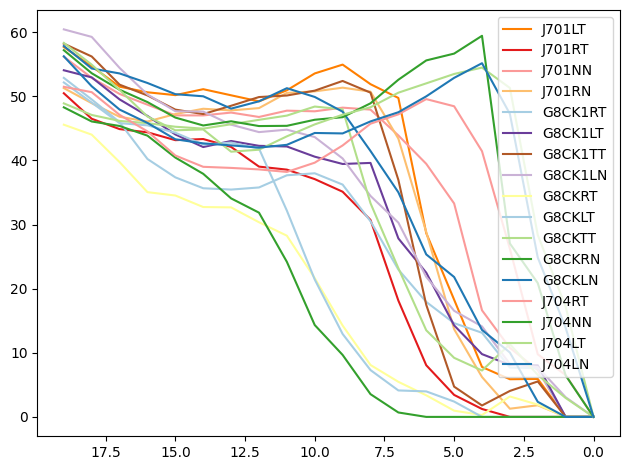

In [17]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([long_nostart])

data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
color_dict = create_color_dict(data,'animal','Paired',sort=False)

for ob,ob_df in  data.groupby(['animal']):
    print(len(ob_df))
    print(len(ob_df.animal.unique()))
    
    rows = ob_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(ob_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    color = color_dict.get(ob)
    task_angle_median= np.nanmedian(angle_array,axis = 0)
    ax.plot(xnew,task_angle_median,c = color,alpha = 1)
    ax.legend(color_dict)

In [20]:
long_nostart.num_turn

AttributeError: 'DataFrame' object has no attribute 'num_turn'

In [18]:
long_nostart.groupby(['date']).num_turn.mean()

AttributeError: 'DataFrameGroupBy' object has no attribute 'num_turn'

In [55]:
long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')&(long.obstacle_cross == True)&(long.date_index == 3)].animal

10175    J704RT
10190    J704RT
10192    J704RT
10205    J704RT
10218    J704RT
10219    J704RT
10224    J704RT
10233    J704RT
10239    J704RT
10244    J704RT
10246    J704RT
10264    J704RT
10265    J704RT
10267    J704RT
10271    J704RT
10295    J704NN
10317    J704NN
10319    J704NN
10320    J704NN
10339    J704NN
10341    J704NN
10361    J704NN
10363    J704NN
10365    J704NN
10462    J704LT
10464    J704LT
10467    J704LT
10469    J704LT
10471    J704LT
10522    J704LT
10523    J704LT
10558    J704LN
10575    J704LN
10577    J704LN
10608    J704LN
10625    J704LN
10627    J704LN
10629    J704LN
10659    J704LN
Name: animal, dtype: object

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


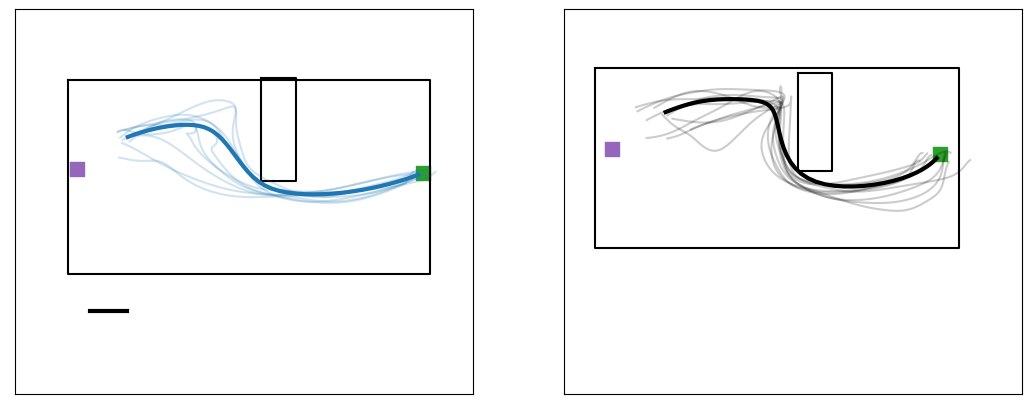

In [66]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
light = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.turn_to_obstacle == 'towards')&(long.obstacle_cross == True)&(long.date_index == 5)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]

dark = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')&(long.obstacle_cross == True)&(long.date_index == 2)]

dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
fig,ax = plt.subplots(1,2,figsize=(13,5),)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plot_arena(light,ax[0])
plot_arena(dark,ax[1])

ob_x,ob_y = plot_orginal_obstacle(light,ax[0],5)
ob_x2,ob_y2 = plot_orginal_obstacle(dark,ax[1],5)

dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))

light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))

ax[1].plot(dark_nose_x,dark_nose_y,color = 'black',linewidth = 3)
ax[0].plot(light_nose_x,light_nose_y,linewidth = 3)

#light_sample = light.sample(10)
for ind,row in light_sample.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:blue')

#dark_sample = dark.sample(10)
for ind,row2 in dark_sample.iterrows():
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    ax[1].plot(x1,y2,alpha = .2 ,c = 'black')

ax[0].plot((10,15),(40,40),c ='black', linewidth = 3)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision\light_dark_traces3.eps',dpi = 300)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision\light_dark_traces3.pdf',dpi = 300)



In [240]:
dark

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,turn_to_obstacle,obstacle_cross,head_corner_angle_velocity_at_head_turn,angle_at_head_turn,distance_traveled_at_head_turn,ts_zero_out_angle_to_target_port,distance_at_head_turn_2,distance_at_head_turn_2_index,angle_at_head_turn_2,num_turn
14188,14188,57397.199180,57400.390131,"[57397.203366, 57397.219187, 57397.235993, 573...","[1740, 1741, 1742, 1743, 1744, 1745, 1746, 174...","[89.42020416259766, 89.51045989990234, 89.6040...","[265.850341796875, 265.421142578125, 265.28167...","[98.70488739013672, 98.4933853149414, 98.62605...","[260.5607604980469, 259.7718811035156, 259.910...","[96.83868408203125, 96.39781188964844, 96.4283...",...,away,True,-6.062212,25.677787,12.935801,"[12.27730070375781, 12.071694527065215, 16.541...",13.485632,13.0,30.682851,2.0
14198,14198,57439.075955,57441.681126,"[57439.083891, 57439.100185, 57439.116966, 574...","[4252, 4253, 4254, 4255, 4256, 4257, 4258, 425...","[87.77692413330078, 88.35308074951172, 88.6996...","[265.8630676269531, 265.9204406738281, 265.773...","[96.05032348632812, 96.1327133178711, 96.15105...","[259.90875244140625, 259.5936279296875, 259.54...","[94.64134216308594, 94.38237762451172, 94.3733...",...,away,True,-6.308828,27.319853,6.383460,"[17.971054604206323, 19.33963069258105, 21.946...",15.632265,6.0,35.080444,1.0
14229,14229,57541.402611,57543.061683,"[57541.41902, 57541.435968, 57541.452364, 5754...","[10390, 10391, 10392, 10393, 10394, 10395, 103...","[90.4993667602539, 90.375732421875, 91.0711059...","[264.1121826171875, 263.5672302246094, 263.819...","[94.97181701660156, 94.7359619140625, 95.33649...","[266.2447814941406, 265.62530517578125, 265.49...","[100.41966247558594, 99.67301177978516, 99.245...",...,away,True,-8.052760,42.024193,4.964854,"[18.454261435718657, 19.921870754701853, 17.46...",14.592011,5.0,47.223035,1.0
14238,14238,57573.153369,57575.176998,"[57573.163097, 57573.179891, 57573.196467, 575...","[12294, 12295, 12296, 12297, 12298, 12299, 123...","[84.5673599243164, 84.74358367919922, 85.09893...","[261.7591247558594, 262.0773010253906, 263.045...","[99.72727966308594, 100.06412506103516, 100.46...","[256.70794677734375, 256.840087890625, 257.688...","[90.61195373535156, 91.00721740722656, 91.3476...",...,away,True,-7.541463,45.133187,10.522077,"[18.713832860642512, 19.70559920490534, 20.981...",8.989273,18.0,51.243862,2.0
14240,14240,57577.421836,57579.568358,"[57577.431283, 57577.447769, 57577.464844, 575...","[12550, 12551, 12552, 12553, 12554, 12555, 125...","[89.22614288330078, 89.10655212402344, 89.2762...","[265.59820556640625, 265.6748962402344, 264.78...","[95.78913116455078, 95.87630462646484, 96.0209...","[260.08990478515625, 260.6557312011719, 260.18...","[95.84304809570312, 95.52698516845703, 95.5024...",...,away,True,-7.049505,36.929566,14.796681,"[15.284351037574673, 13.201808760994677, 11.01...",11.685625,14.0,42.966534,1.0
14364,14364,56728.532544,56733.861939,"[56728.548595, 56728.564569, 56728.581516, 567...","[12678, 12679, 12680, 12681, 12682, 12683, 126...","[87.28778076171875, 86.2567138671875, 85.68518...","[261.35992431640625, 261.7000427246094, 261.31...","[103.08158874511719, 102.46891784667969, 101.5...","[255.98495483398438, 257.12261962890625, 257.4...","[95.14559936523438, 94.34056091308594, 93.6772...",...,away,True,-15.252617,0.000000,55.394436,"[58.211791626920714, 48.44962389859264, 44.023...",2.886809,59.0,66.534762,4.0
14366,14366,56736.704716,56740.047398,"[56736.71735, 56736.734041, 56736.751616, 5673...","[13168, 13169, 13170, 13171, 13172, 13173, 131...","[88.77175903320312, 88.9205551147461, 88.98123...","[262.5135803222656, 262.0632019042969, 261.897...","[103.83614349365234, 103.36932373046875, 103.2...","[256.6336669921875, 257.121826171875, 256.7346...","[96.13236999511719, 96.17483520507812, 96.0295...",...,away,True,-7.457426,52.818145,33.464370,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

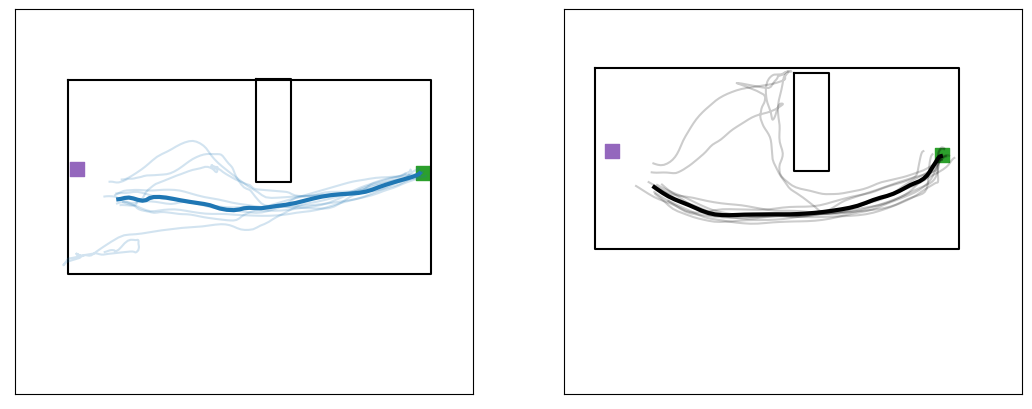

In [243]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
light = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'away')&(long_nostart.obstacle_cross == True)&(long_nostart.date_index == 5)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
#light = light[light.linearity >= .8]

dark = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oadark')&(long_nostart.turn_to_obstacle == 'away')&(long_nostart.obstacle_cross == True)&(long_nostart.date_index == 2)]

dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
#dark = dark[dark.linearity >= .8]
fig,ax = plt.subplots(1,2,figsize=(13,5),)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plot_arena(light,ax[0])
plot_arena(dark,ax[1])

ob_x,ob_y = plot_orginal_obstacle(light,ax[0],5)
ob_x2,ob_y2 = plot_orginal_obstacle(dark,ax[1],5)

dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))

light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))

ax[1].plot(dark_nose_x,dark_nose_y,color = 'black',linewidth = 3)
ax[0].plot(light_nose_x,light_nose_y,linewidth = 3)

light_sample = light
for ind,row in light_sample.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:blue')

dark_sample = dark
for ind,row2 in dark_sample.iterrows():
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    ax[1].plot(x1,y2,alpha = .2 ,c = 'black')

fig.savefig(r'd:\obstacle_avoidance\figures\SFN/vis_nav\light_dark_traces3_away.pdf',dpi = 300)

In [236]:
dark

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,turn_to_obstacle,obstacle_cross,head_corner_angle_velocity_at_head_turn,angle_at_head_turn,distance_traveled_at_head_turn,ts_zero_out_angle_to_target_port,distance_at_head_turn_2,distance_at_head_turn_2_index,angle_at_head_turn_2,num_turn
14286,14286,55040.020019,55041.777369,"[55040.030604, 55040.04727, 55040.065356, 5504...","[7792, 7793, 7794, 7795, 7796, 7797, 7798, 779...","[88.40460968017578, 88.39478302001953, 88.8827...","[265.91845703125, 264.074951171875, 262.901184...","[93.56230163574219, 92.86640930175781, 92.9663...","[270.1909484863281, 267.02569580078125, 265.77...","[99.47542572021484, 98.6947021484375, 97.78918...",...,towards,True,-6.479527,47.646439,4.186779,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,0.0
14294,14294,55124.347225,55126.780505,"[55124.360499, 55124.376448, 55124.393164, 551...","[12850, 12851, 12852, 12853, 12854, 12855, 128...","[81.91546630859375, 82.04035949707031, 81.9932...","[263.5642395019531, 263.2248229980469, 262.594...","[89.14148712158203, 88.77940368652344, 88.9004...","[259.869140625, 259.43853759765625, 259.226287...","[90.51782989501953, 90.44520568847656, 90.3370...",...,towards,True,-9.324154,58.205078,22.273312,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.907081,26.0,66.736182,2.0


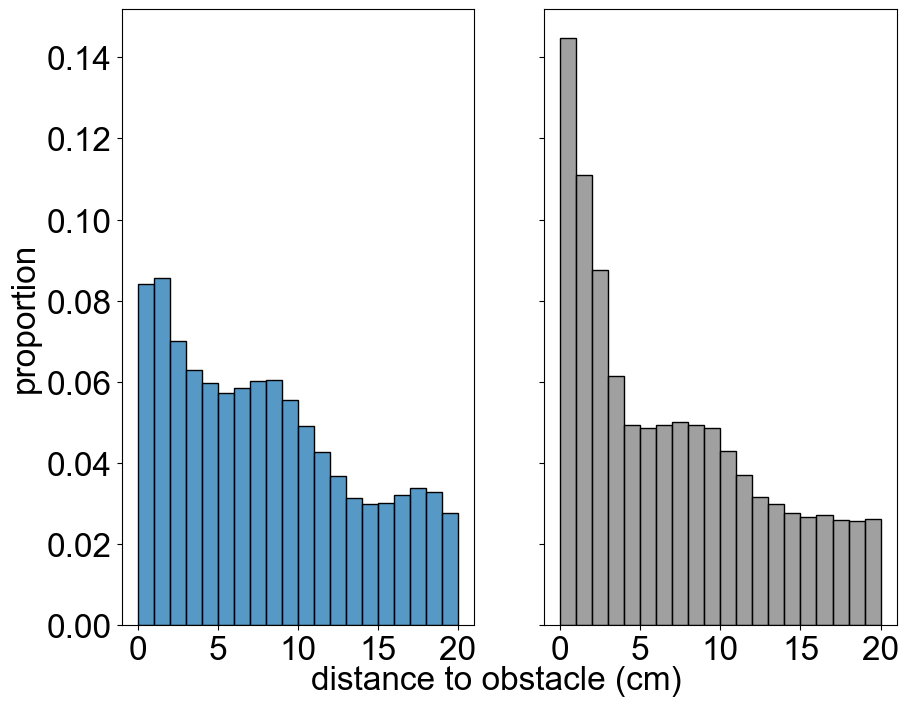

In [118]:
data = pd.concat([joint])
dark = data[data.task =='oadark']
light = data[data.task =='oa']

fig,ax = plt.subplots(1,2,figsize=(10,8),sharey =True)

light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_list())
light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=20))]
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_list())
dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=20))]

sns.histplot(data = light_dist,ax =ax[0],stat='proportion',bins=20,color = 'tab:blue')
sns.histplot(data = dark_dist,ax =ax[1],stat='proportion',bins=20,color = 'grey')

ax[0].set_xticks([0,5,10,15,20])

ax[1].set_xticks([0,5,10,15,20])

ax[0].set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/vis_nav\distance_dist.png',dpi = 300)


In [ ]:
sns.barplot(data = long[long.date_index == 3], x ='task',y ='distance_at_min_ang',estimator='median')

Text(0.5, 0.04, 'distance to obstacle (cm)')

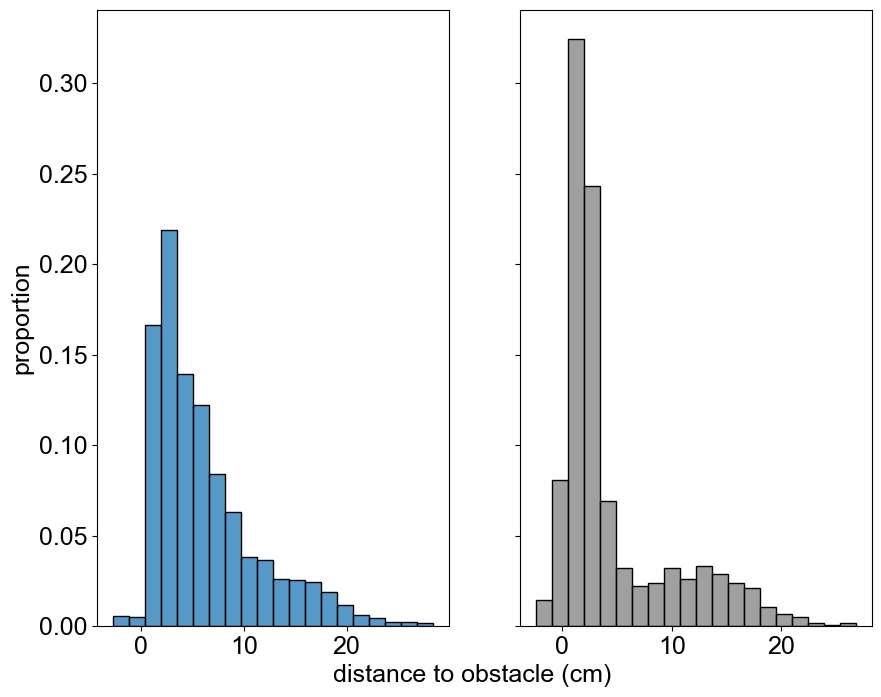

In [177]:
dark = long[long.task =='oadark']
light = long[long.task =='oa']

fig,ax = plt.subplots(1,2,figsize=(10,8),sharey =True)

#light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_list())
#light_dist = light_dist[np.where((light_dist>=0))]
#light_dist = light_dist[np.where((light_dist<=20))]
#dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_list())
#dark_dist = dark_dist[np.where((dark_dist>=0))]
#dark_dist = dark_dist[np.where((dark_dist<=20))]
#
sns.histplot(data = light,x='distance_at_min_ang', ax =ax[0],stat='proportion',bins=20,color = 'tab:blue')
sns.histplot(data = dark,x='distance_at_min_ang', ax =ax[1],stat='proportion',bins=20,color = 'grey')

#ax[0].set_xticks([0,5,10,15,20])

#ax[1].set_xticks([0,5,10,15,20])

ax[0].set_ylabel('proportion')
ax[0].set_xlabel('')
ax[1].set_xlabel('')
fig.text(0.5, 0.04, 'distance to obstacle (cm)', ha='center')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision\distance_dist.pdf',dpi = 300)

meta NOT subset; don't know how to subset; dropped


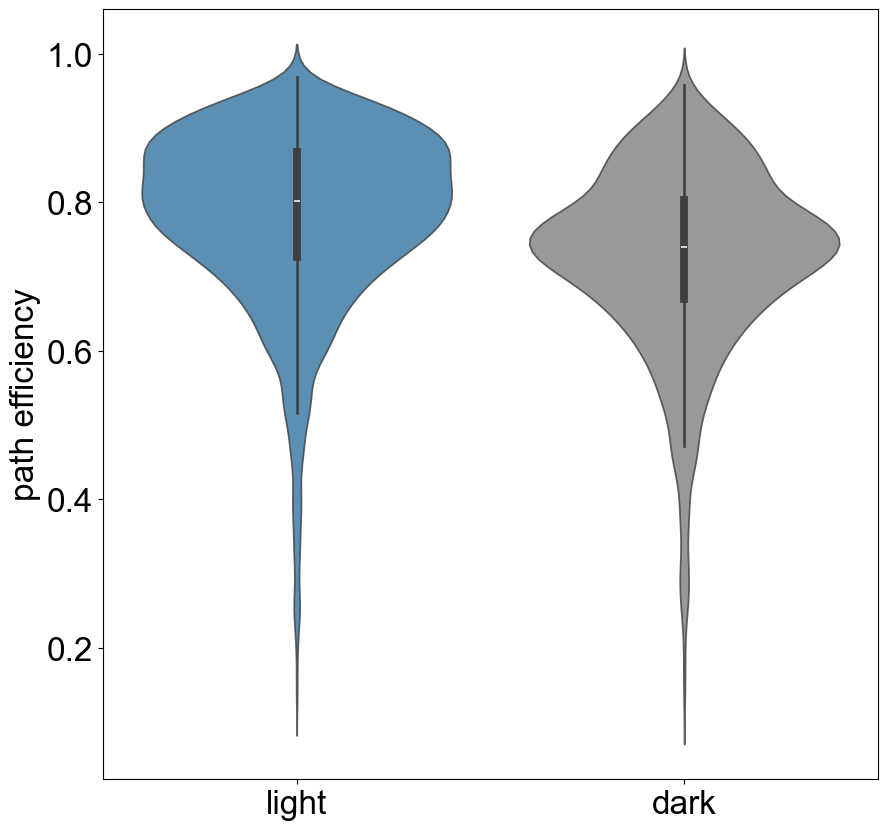

In [126]:

fig,ax = plt.subplots( figsize= (10,10))
color = ['tab:blue','grey']
data = pd.concat([joint])
data = data[data.turn_to_obstacle == 'towards']

sns.violinplot(data = data, x ='task', y = 'linearity', hue = 'task',ax = ax,palette = color,alpha = .8)
ax.set_xticks([0,1],['light','dark'])
ax.set_xlabel('')
ax.set_ylabel('path efficiency')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/vis_nav\path_efficiency.pdf',dpi = 300)


Text(0.5, 0.03, 'distance to obstacle (cm)')

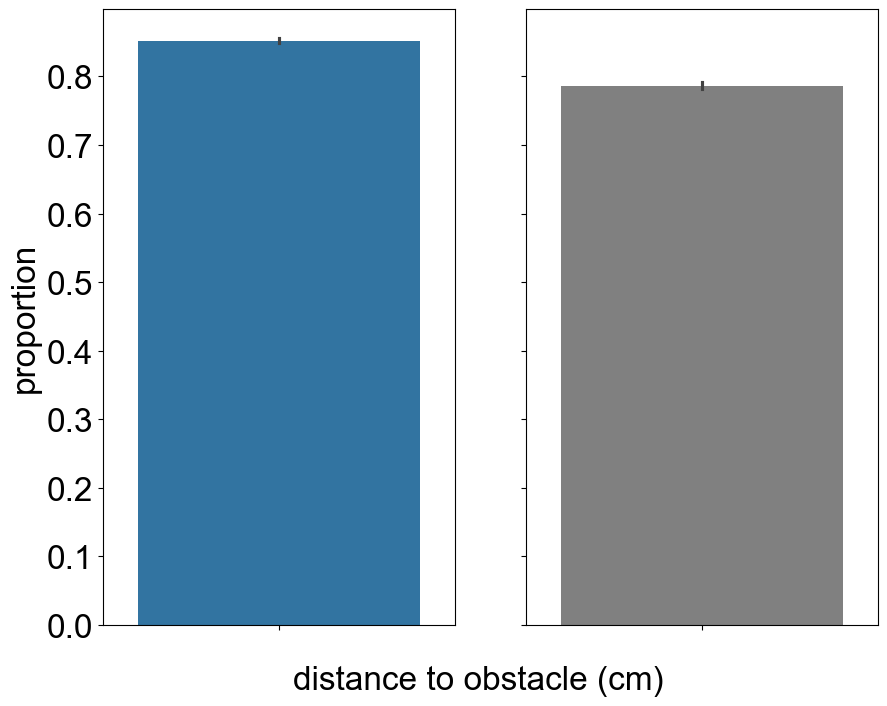

In [134]:
data = pd.concat([joint])
dark = data[data.task =='oadark']
light = data[data.task =='oa']

fig,ax = plt.subplots(1,2,figsize=(10,8),sharey =True)

#ight_dist = light.linearity.to_list()
#light_dist = light_dist[np.where((light_dist>=0))]
#light_dist = light_dist[np.where((light_dist<=20))]
#dark_dist = dark.linearity.to_list()
#dark_dist = dark_dist[np.where((dark_dist>=0))]
#dark_dist = dark_dist[np.where((dark_dist<=20))]

sns.barplot(data = light,y = 'linearity',ax =ax[0],color = 'tab:blue',estimator='median')
sns.barplot(data = dark,y = 'linearity',ax =ax[1],color = 'grey',estimator='median')

#ax[0].set_xticks([0,5,10,15,20])

#ax[1].set_xticks([0,5,10,15,20])

ax[0].set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')

In [149]:
np.round(light.linearity.median(),2)

0.85

In [170]:
dark.linearity.median()

0.7858323184330942

In [168]:
light.linearity.median()

0.8521371404242482

In [220]:
dark.linearity.to_numpy()[dark.linearity.to_numpy()>=.4].mean()

0.7805838562129683

In [219]:
light.linearity.to_numpy()[light.linearity.to_numpy()>=.4].mean()

0.8251875651093015

Text(0.5, 0.03, 'path efficiency')

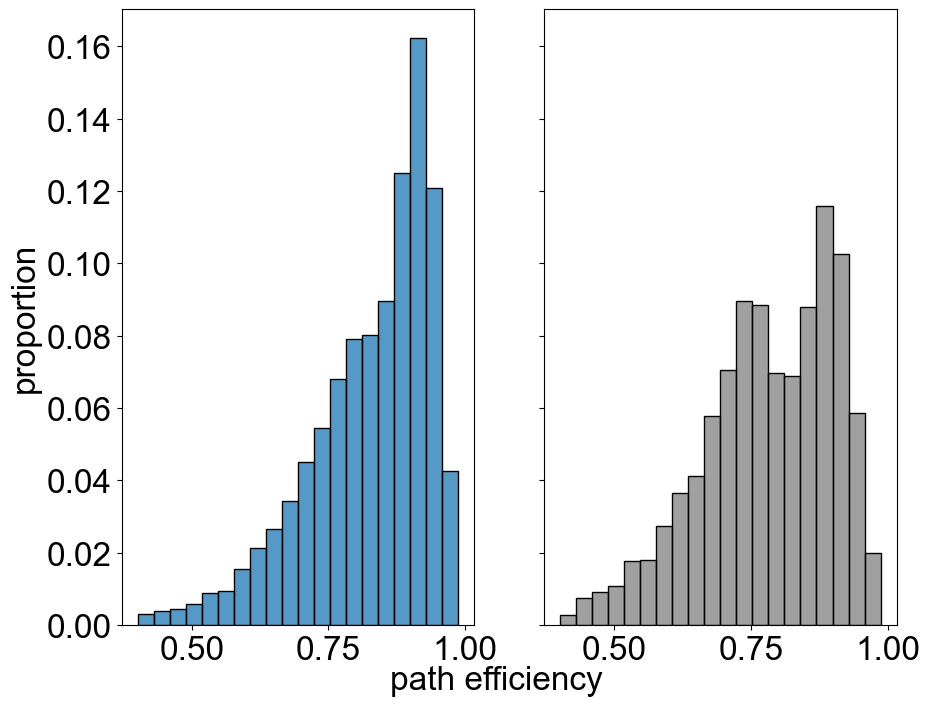

In [226]:
data = pd.concat([joint])
#data =data[data.turn_to_obstacle == 'towards']
dark = data[data.task =='oadark']
light = data[data.task =='oa']

fig,ax = plt.subplots(1,2,figsize=(10,8),sharey =True)

light_dist = light.linearity.to_numpy()
light_dist = light_dist[light_dist>=0.4]
#light_dist = light_dist[np.where((light_dist<=20))]
dark_dist = dark.linearity.to_numpy()
dark_dist = dark_dist[dark_dist>=0.4]
#dark_dist = dark_dist[np.where((dark_dist<=20))]

sns.histplot(data = light_dist,ax =ax[0],stat='proportion',bins=20,color = 'tab:blue')
sns.histplot(data = dark_dist,ax =ax[1],stat='proportion',bins=20,color = 'grey')

#ax[0].set_xticks([0,5,10,15,20])

#ax[1].set_xticks([0,5,10,15,20])

#ax[0].axvline(light.linearity.mean(), color='r', ls=':',linewidth = 2)
#ax[0].text(light.linearity.mean() - .15, ax[0].get_ylim()[1]/2,'mean ' + str(np.round(light.linearity.mean(),2)), color='black', ha='right', va='top', rotation=360,fontsize=16)
#ax[1].axvline(dark.linearity.mean(), color='r', ls=':',linewidth = 2)
#ax[1].text(dark.linearity.mean() - .16, ax[0].get_ylim()[1]/2,'mean ' + str(np.round(dark.linearity.mean(),2)), color='black', ha='right', va='top', rotation=360,fontsize=16)

ax[0].set_ylabel('proportion')
fig.text(0.5, 0.03, 'path efficiency', ha='center')

In [ ]:
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision\distance_dist.pdf',dpi = 300)

In [49]:
#data = long[(long.obstacle_cluster == 0)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks(np.arange(-1,20,6))
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('Heading to the opening (deg)')
    ax[1].set_xlabel('Distance to obstacle')
    #ax[2].invert_xaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:blue')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.ts_zero_out_angle_to_corner[:ob_ind]),color = 'tab:blue')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'Obstacle edge', color='r', ha='right', va='center', rotation=90)
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'tab:blue')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/heading_to_opening_light.pdf') 

NameError: name 'sample' is not defined

In [116]:
ob_ind = int(row.obstacle_ind)
row.ts_speed[:ob_ind].max()

48.83605494030998

In [123]:
def peak_speed(df):
    for ind, row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'peak_speed'] = row.ts_speed[:ob_ind].max()


In [178]:
def min_angle(df):
    for ind,row in df.iterrows():
        thresh = row.ts_angle_to_corner[:int(row.obstacle_ind)].argmin()
        df.at[ind,'distance_at_min_ang'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh]
        df.at[ind,'min_ang'] =row.ts_angle_to_corner[:int(row.obstacle_ind)].min()
        df.at[ind,'min_ang_ind'] =thresh
     

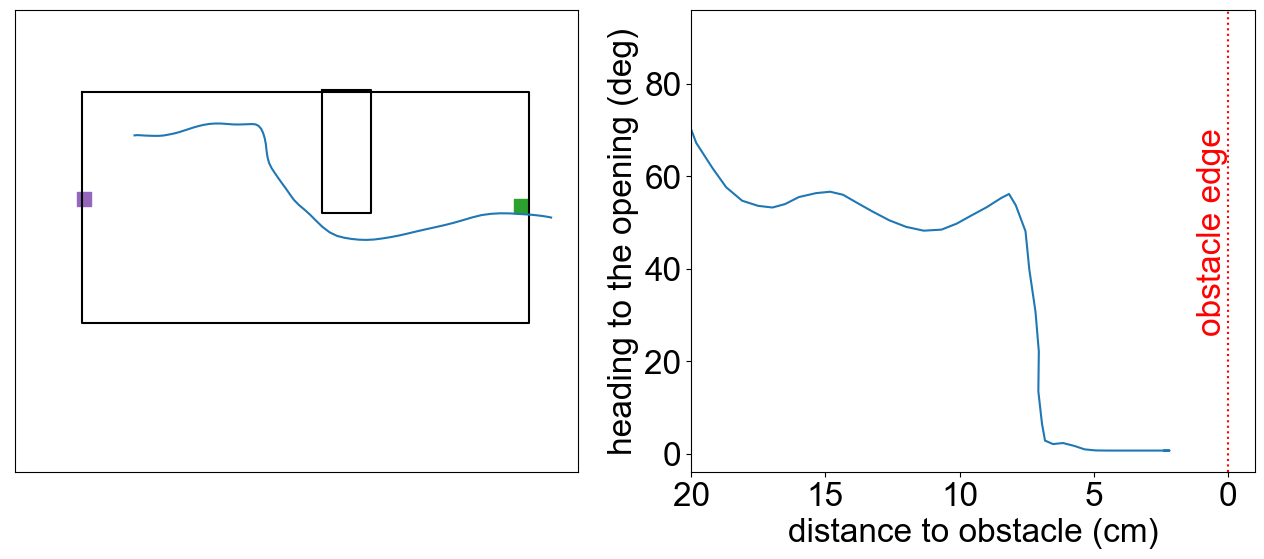

In [99]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('heading to the opening (deg)')
    ax[1].set_xlabel('distance to obstacle')
    #ax[2].invert_xaxis()
    plot_arena(data,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(x,y,color = 'tab:blue')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.ts_zero_out_angle_to_corner[:ob_ind]),color = 'tab:blue')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'tab:blue')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision/heading_to_opening_light.pdf')
     

In [62]:
smooth(row.ts_zero_out_angle_to_corner[:ob_ind])

array([6.02990906e+01, 5.91116353e+01, 5.73114689e+01, 5.53654103e+01,
       5.29671613e+01, 5.01709681e+01, 4.78412457e+01, 4.70210511e+01,
       4.79688344e+01, 4.95546198e+01, 5.10502379e+01, 5.22361010e+01,
       5.30205592e+01, 5.40349471e+01, 5.51417052e+01, 5.63142596e+01,
       5.79499284e+01, 6.04447607e+01, 6.36207941e+01, 6.59855751e+01,
       6.62761662e+01, 6.40110145e+01, 5.98310101e+01, 5.46716154e+01,
       4.84470016e+01, 4.17562763e+01, 3.44215308e+01, 2.58037928e+01,
       1.73094773e+01, 1.05433334e+01, 5.29687532e+00, 1.74688050e+00,
       2.97056443e-01, 2.18364017e-02, 6.17615671e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

meta NOT subset; don't know how to subset; dropped


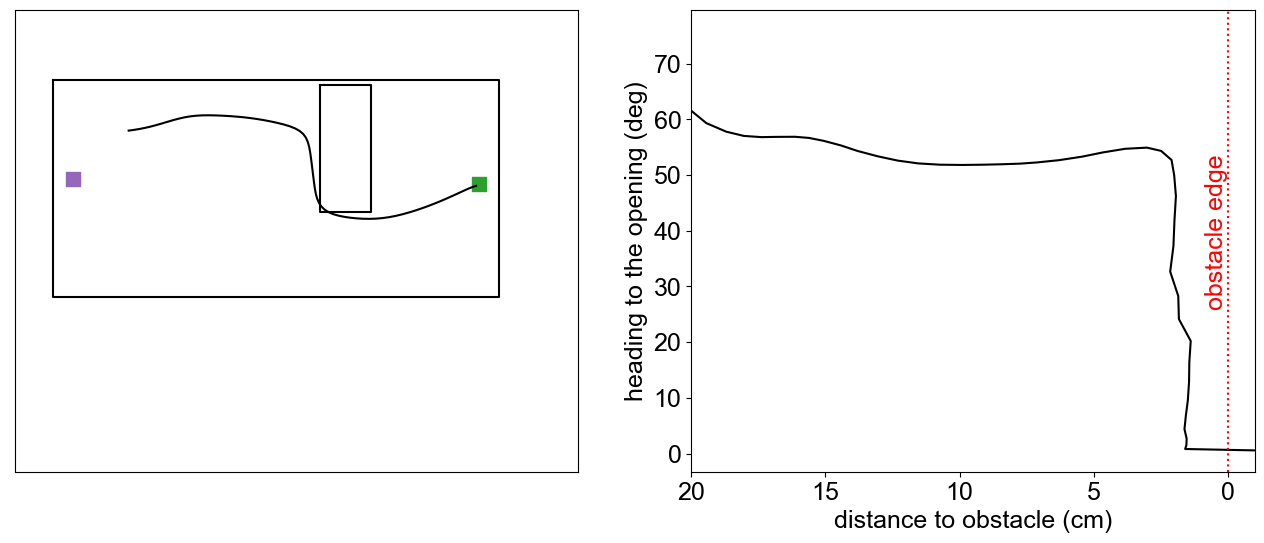

In [82]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('heading to the opening (deg)')
    ax[1].set_xlabel('distance to obstacle')
    #ax[2].invert_xaxis()
    plot_arena(sample,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(x,y,color = 'black')
        #ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'black')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.ts_zero_out_angle_to_corner[:ob_ind]),color = 'black')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision/heading_to_opening_dark.pdf')

In [243]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,ts_total_distance,intial_head_angle_velocity,turn_direction,turn_direction_end,turn_to_obstacle,obstacle_cross,head_corner_angle_velocity_at_head_turn,angle_at_head_turn,distance_traveled_at_head_turn,ts_zero_out_angle_to_target_port
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,91.543341,-0.788911,up,down,towards,True,-4.804871,43.833643,43.418439,"[22.04616869944721, 28.159448450055024, 33.387..."
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,84.350043,-0.163803,down,down,away,True,-4.175209,67.816385,5.877207,"[29.27554420899936, 28.02386546266077, 28.1157..."
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,71.480402,-0.207297,up,down,towards,True,-3.941995,45.577346,4.505404,"[5.4985704164487395, 9.649263258632539, 7.2602..."
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,88.411867,-0.160381,up,down,towards,True,-5.014465,49.631036,30.596654,"[25.897982581342898, 24.269517945326385, 20.31..."
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,101.233985,0.232069,down,down,away,True,-10.914356,88.576692,51.614339,"[40.880691394021795, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[256.0437316894531, 256.8573913574219, 257.122...","[94.1467056274414, 93.94309997558594, 93.60278...",...,62.618490,1.676589,down,up,towards,True,-7.609932,48.877167,22.281034,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14459,14459,58310.359923,58312.854592,"[58310.360256, 58310.376601, 58310.39406, 5831...","[12229, 12230, 12231, 12232, 12233, 12234, 122...","[86.841064453125, 86.9388427734375, 86.4898529...","[257.9836730957031, 258.0146179199219, 257.881...","[104.91130065917969, 103.79759979248047, 102.6...","[253.5960235595703, 253.80740356445312, 254.47...","[93.63558959960938, 92.92048645019531, 92.4770...",...,62.278480,1.071151,d

In [244]:
row[1]['distance_at_head_turn']

0.835773462157885

In [241]:
row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)

array([20.04359739, 19.93907257, 19.74508133, 19.48719375, 19.19446995,
       18.89288893, 18.60144875, 18.33156868, 18.08880619, 17.87533868,
       17.69173115, 17.53748213, 17.41067199, 17.30746234, 17.22204217,
       17.14711413, 17.07457745, 16.99607279, 16.9032255 , 16.78787551,
       16.64241218, 16.46022434, 16.2361335 , 15.96659883, 15.64981659,
       15.28579931, 14.87660224, 14.42649569, 13.94190098, 13.43086265,
       12.90202545, 12.36337831, 11.82118966, 11.27954814, 10.74064207,
       10.20553494,  9.67494707,  9.14959393,  8.62994397,  8.11565033,
        7.60511097,  7.09562226,  6.58424122,  6.06906212,  5.55021472,
        5.03013553,  4.513002  ,  4.00392187,  3.50856579,  3.03350112,
        2.58686209,  2.17845062,  1.81873717,  1.51669615,  1.27732711,
        1.09996334,  0.97820059,  0.90150548,  0.85777454,  0.83577346,
        0.82667347,  0.82446528,  0.82557117,  0.82810983,  0.83120379,
        0.83449184,  0.837841  ,  0.8412054 ,  0.84457099,  0.84

In [240]:
row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)

array([80.89724402, 78.00613185, 70.45755358, 71.51781406, 68.58414197,
       66.84934277, 68.63955303, 61.9513465 , 68.25419795, 67.75622013,
       66.40447994, 66.07446665, 66.11959486, 74.3452191 , 74.09917759,
       75.85295515, 75.85273354, 73.64784881, 71.1114777 , 69.57941633,
       62.55546251, 55.71652422, 48.28630012, 44.50335228, 40.31786439,
       35.27413697, 30.09595809, 27.1146099 , 26.8873053 , 26.60561688,
       25.76905609, 24.58721427, 24.76544235, 28.53302638, 29.36960653,
       27.08635216, 27.46808896, 31.73758763, 32.05828608, 39.12357746,
       38.96845208, 42.74557143, 46.73944294, 48.86311177, 50.3617194 ,
       50.7369699 , 55.62167006, 58.9331258 , 59.5644822 , 62.88632877,
       68.73582152, 70.90632082, 69.7789027 , 71.61038055, 81.0620642 ,
       88.38895283, 81.72901471, 72.78226805, 58.37654944, 43.52591004,
       31.42620081, 25.68731863, 18.1147925 , 14.15249411, 10.36126662,
        8.23537976,  6.79763576,  5.02048486,  3.95467694,  3.22

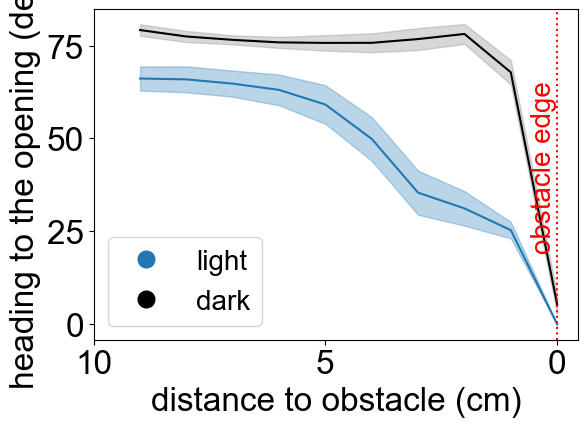

In [16]:
xnew =  np.arange(0, 10, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)

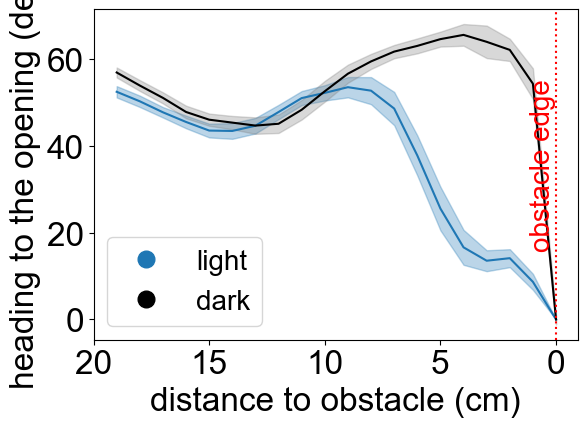

In [17]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([long_nostart,short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)

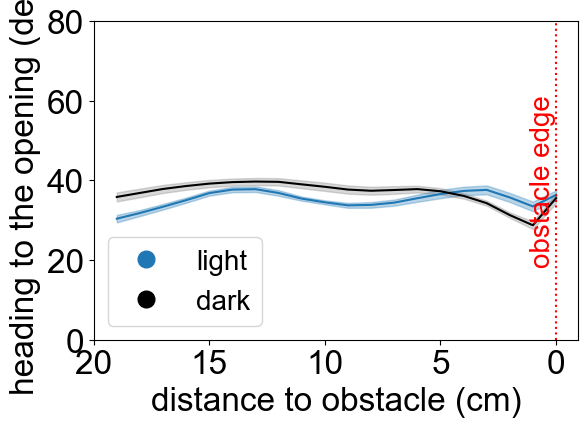

In [34]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)

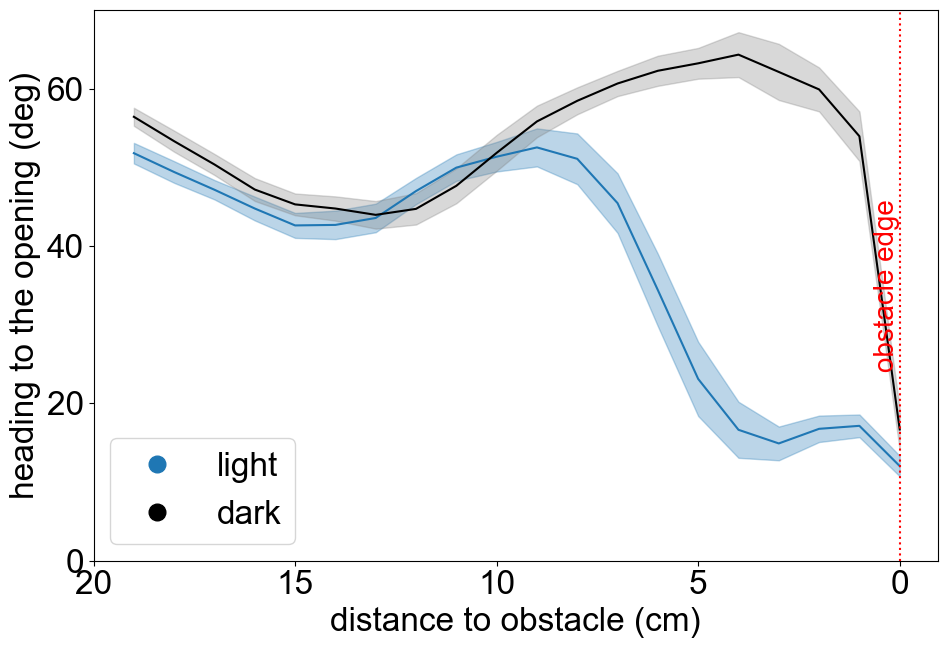

In [227]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision/heading_to_opening.pdf',dpi = 300)

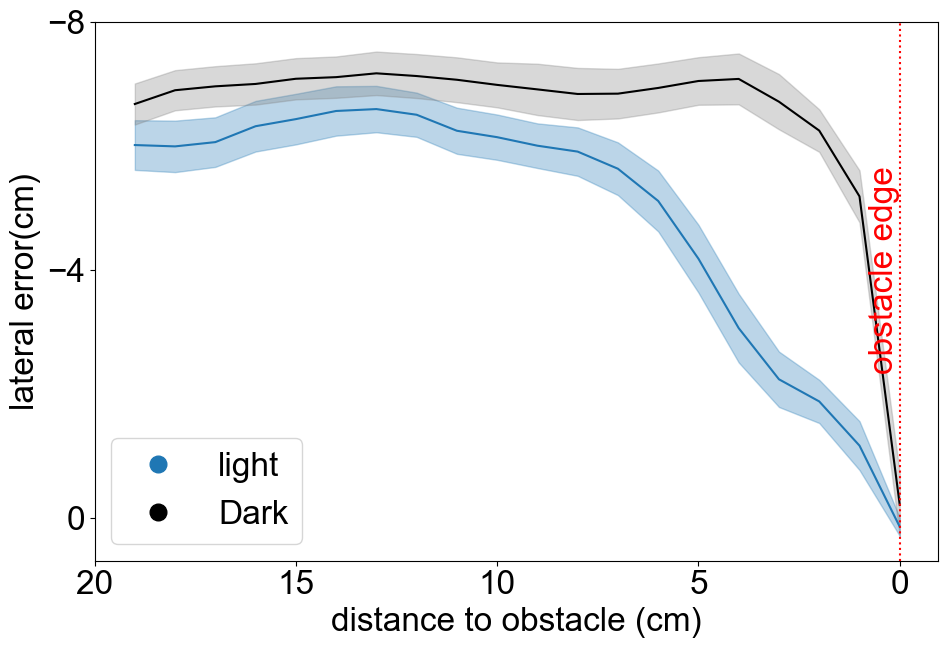

In [117]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )


ax.invert_xaxis()
ax.invert_yaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = drop_nans_in_columns(data,'lateral_error')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])   
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=24)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','Dark'], numpoints=1,loc = 'lower left',fontsize=24)

In [28]:
task_angle_median

array([56.69997354, 53.66949185, 50.7999734 , 47.60296837, 45.50346947,
       44.96872953, 43.72745539, 43.34361399, 43.98070029, 44.72872003,
       45.15116958, 47.37439904, 50.29087897, 52.23100079, 53.98704101,
       53.09810269, 38.65996832, 29.00769155, 14.61871987,  8.40504229])

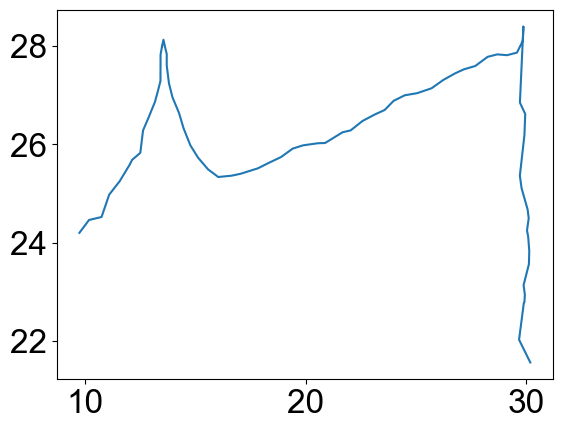

In [10]:
plt.plot(row[1]['ts_nose_x_cm'][:int(row[1]['obstacle_ind'])].astype(float),row[1]['ts_nose_y_cm'][:int(row[1]['obstacle_ind'])].astype(float))

In [9]:
row[1]['ts_nose_y_cm'][:int(row[1]['obstacle_ind'])].astype(float)

array([24.19917182, 24.46008918, 24.52126611, 24.97548529, 25.24978381,
       25.58779459, 25.68229845, 25.82537204, 26.28209055, 26.54092256,
       26.85721337, 27.0733897 , 27.28586846, 27.82032836, 28.00085328,
       27.9909074 , 28.12531563, 27.98795552, 27.83349868, 27.60523457,
       27.2378207 , 26.95463568, 26.63713378, 26.32191778, 25.97458338,
       25.7246533 , 25.48936175, 25.33408209, 25.36135869, 25.39893601,
       25.51035147, 25.62188263, 25.73947183, 25.91134939, 25.97747612,
       26.02013438, 26.02521275, 26.24342813, 26.28145029, 26.47279791,
       26.60457825, 26.69604795, 26.88259748, 26.99499261, 27.03916281,
       27.13820505, 27.30648533, 27.4392582 , 27.52306021, 27.59063459,
       27.77739497, 27.82709095, 27.81042877, 27.86271663, 28.10524645,
       28.39427866, 28.36137009, 28.32846153, 28.29555296, 28.2626444 ,
       28.22973583, 28.19682726, 28.1639187 , 28.13101013, 28.09810157,
       28.065193  , 28.03228443, 27.99937587, 27.9664673 , 27.93

In [12]:
np.round(row[1]['ts_nose_x_cm'][:int(row[1]['obstacle_ind'])].astype(float))

array([10., 10., 11., 11., 12., 12., 12., 13., 13., 13., 13., 13., 13.,
       13., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 15., 15.,
       16., 16., 17., 17., 18., 18., 19., 19., 20., 21., 21., 22., 22.,
       23., 23., 24., 24., 24., 25., 26., 26., 27., 27., 28., 28., 29.,
       29., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30.])

In [6]:
y

array([80.89724402, 78.00613185, 70.45755358, 71.51781406, 68.58414197,
       66.84934277, 68.63955303, 61.9513465 , 68.25419795, 67.75622013,
       66.40447994, 66.07446665, 66.11959486, 74.3452191 , 74.09917759,
       75.85295515, 75.85273354, 73.64784881, 71.1114777 , 69.57941633,
       62.55546251, 55.71652422, 48.28630012, 44.50335228, 40.31786439,
       35.27413697, 30.09595809, 27.1146099 , 26.8873053 , 26.60561688,
       25.76905609, 24.58721427, 24.76544235, 28.53302638, 29.36960653,
       27.08635216, 27.46808896, 31.73758763, 32.05828608, 39.12357746,
       38.96845208, 42.74557143, 46.73944294, 48.86311177, 50.3617194 ,
       50.7369699 , 55.62167006, 58.9331258 , 59.5644822 , 62.88632877,
       68.73582152, 70.90632082, 69.7789027 , 71.61038055, 81.0620642 ,
       88.38895283, 81.72901471, 72.78226805, 58.37654944, 43.52591004,
       31.42620081, 25.68731863, 18.1147925 , 14.15249411, 10.36126662,
        8.23537976,  6.79763576,  5.02048486,  3.95467694,  3.22

In [31]:
sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,turn_direction,turn_direction_end,turn_to_obstacle,obstacle_cross,head_corner_angle_velocity_at_head_turn,angle_at_head_turn,distance_traveled_at_head_turn,ts_zero_out_angle_to_target_port,consective_inds,consective_type
3364,3364,54979.873856,54982.462796,"[54979.881459, 54979.898393, 54979.915788, 549...","[[6871, 6872, 6873, 6874, 6875, 6876, 6877, 68...","[690.9060668945312, 691.1382446289062, 691.611...","[271.0107727050781, 270.8990478515625, 271.453...","[680.927001953125, 681.3095703125, 682.2862548...","[262.8451232910156, 262.5636291503906, 263.138...","[683.3098754882812, 683.7190551757812, 683.634...",...,up,up,towards,True,-4.243793,28.820380,21.057144,"[13.582647388056458, 3.8529873034697117, 2.459...","[3362, 3363, 3364]",2
4128,4128,49238.773043,49242.381900,"[49238.788134, 49238.804224, 49238.820787, 492...","[[3102, 3103, 3104, 3105, 3106, 3107, 3108, 31...","[692.5330810546875, 692.964599609375, 692.9634...","[270.1167297363281, 270.7869873046875, 270.312...","[686.0494384765625, 685.9481201171875, 686.513...","[260.58697509765625, 261.3409729003906, 260.77...","[686.964599609375, 687.41845703125, 687.946716...",...,up,down,towards,True,-3.478464,62.750821,24.837711,"[18.89383017512087, 12.419223212990175, 20.348...","[4126, 4127, 4128]",2
4142,4142,49282.394995,49285.057651,"[49282.402444, 49282.420198, 49282.43598, 4928...","[[5718, 5719, 5720, 5721, 5722, 5723, 5724, 57...","[691.63427734375, 692.2596435546875, 692.29364...","[268.8317565917969, 268.3630676269531, 269.101...","[681.2057495117188, 682.3402709960938, 683.764...","[259.8705139160156, 259.71514892578125, 260.62...","[684.3330078125, 685.341796875, 685.8115234375...",...,up,down,towards,True,-7.505924,54.666492,31.726566,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[4140, 4141, 4142]",2
4541,4541,53214.827865,53217.355289,"[53214.842636, 53214.860134, 53214.875929, 532...","[[6659, 6660, 6661, 6662, 6663, 6664, 6665, 66...","[692.3560791015625, 692.8568725585938, 693.061...","[269.9240417480469, 269.6634521484375, 270.902...","[683.7274169921875, 684.4171142578125, 685.783...","[259.47650146484375, 259.3346862792969, 260.34...","[684.56396484375, 685.5003051757812, 686.91827...",...,up,up,towards,True,-3.098226,25.742412,17.317073,"[8.271621035038429, 6.837590663770613, 0.46405...","[4539, 4540, 4541]",2
4579,4579,53351.498150,53354.119808,"[53351.506073, 53351.522752, 53351.539456, 533...","[[14856, 14857, 14858, 14859, 14860, 14861, 14...","[691.5501098632812, 692.8226928710938, 693.090...","[270.138427734375, 269.505859375, 269.45968627...","[682.2399291992188, 683.749267578125, 684.8129...","[260.5767517089844, 260.2740783691406, 260.153...","[684.2910766601562, 685.7335815429688, 686.738...",...,up,up,towards,True,-6.577352,45.507600,22.297486,"[18.64822011412988, 6.803500616908958, 0.07407...","[4577, 4578, 4579, 4580, 4581]",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,581,42655.727040,42659.917657,"[42655.729331, 42655.746035, 42655.763059, 426...","[35495, 35496, 35497, 35498, 35499, 35500, 355...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[101.76725769042969, 101.57782745361328, 102.2...","[233.73324584960938, 233.16549682617188, 233.0...","[101.46714782714844, 101.15279388427734, 101.1...",...,down,down,towards,False,-5.324489,33.550848,19.026727,"[7.449252298581296, 8.573680416586399, 9.81944...","[579, 580, 581]",2
1625,1625,42263.120537,42266.012505,"[42263.130342, 42263.14766, 42263.163712, 4226...","[2922, 2923, 2924, 2925, 2926, 2927, 2928, 292...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[98.68145751953125, 98.81842041015625, 99.2648...","[231.9677734375, 231.88595581054688, 231.14564...","[101.09614562988281, 100.7114028930664, 101.

In [67]:
from matplotlib import rcParams
rcParams.update({'figure.autolayout': False})

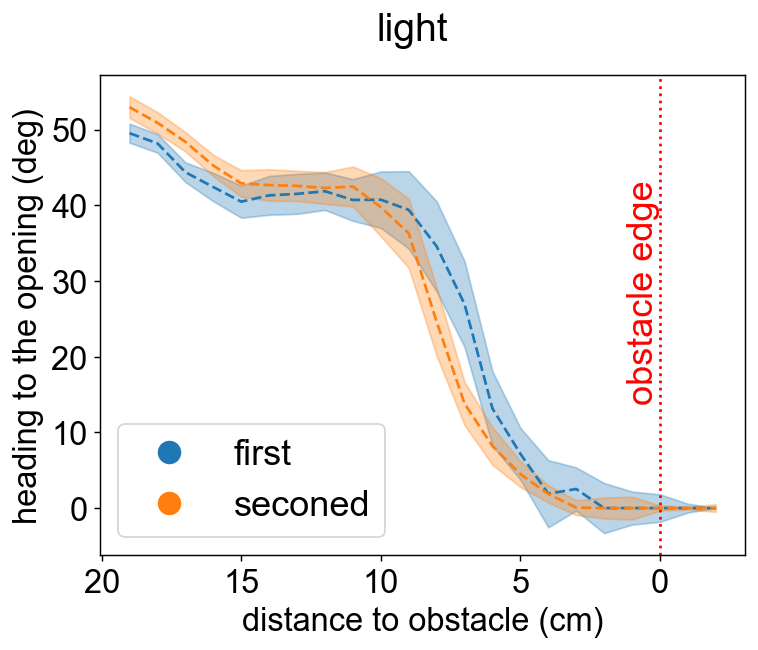

In [71]:
""" Angle to corner comparing fisr and third trials """
xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
ax.invert_xaxis()
fig.suptitle('light')
data = long_con_nostart
long_short = pd.concat([long_con_nostart,short_con_nostart])
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
data = drop_nans_in_columns(data,'speed')

first_trial = data[(data.task == 'oa')&(data.consective_type == 0)&(data.turn_to_obstacle == 'towards')]
ind = first_trial.index.to_numpy()+2
third_trial = data[(data.task == 'oa')&(data.consective_type == 2)&(data.turn_to_obstacle == 'towards')]

fist_light_medians = []
fist_dark_medians = []
fist_light_sd = []
fist_dark_sd = []

sec_light_medians = []
sec_dark_medians = []
sec_light_sd = []
sec_dark_sd = []


first_rows = first_trial.shape[0]
first_angle_array = np.empty([first_rows,len(xnew)])
first_angle_array[:] =np.nan 
for i,row in enumerate(first_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        first_angle_array[i] = ynew

first_angle_median= np.nanmedian(first_angle_array,axis = 0)
    
for animal,animal_df in first_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            fist_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

fist_light_medians = np.asarray(fist_light_medians)


for i in list(range(fist_light_medians.shape[1])):
    sd = np.nanstd(fist_light_medians[:,i])/np.sqrt(len(fist_light_medians[:,i]))
    fist_light_sd.append(sd)
fist_light_sd = np.asarray(fist_light_sd)


ax.plot(xnew,first_angle_median,'--',c = 'tab:blue',alpha = 1)
ax.fill_between(xnew, first_angle_median-fist_light_sd, first_angle_median+fist_light_sd, color='tab:blue', alpha=0.3, label='IQR')  
third_rows = third_trial.shape[0]
third_angle_array = np.empty([third_rows,len(xnew)])
third_angle_array[:] =np.nan 
for i,row in enumerate(third_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        third_angle_array[i] = ynew
third_angle_mean = np.nanmean(third_angle_array,axis = 0)
third_angle_median= np.nanmedian(third_angle_array,axis = 0)
for animal,animal_df in third_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            sec_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

sec_light_medians = np.asarray(sec_light_medians)


for i in list(range(sec_light_medians.shape[1])):
    sd = np.nanstd(sec_light_medians[:,i])/np.sqrt(len(sec_light_medians[:,i]))
    sec_light_sd.append(sd)
sec_light_sd = np.asarray(sec_light_sd)
ax.plot(xnew,third_angle_median,'--',c = 'tab:orange',alpha = 1)
ax.fill_between(xnew, third_angle_median-sec_light_sd, third_angle_median+sec_light_sd, color='tab:orange', alpha=0.3, label='IQR')  





ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','tab:orange']]
ax.legend(markers, ['first','seconed'], numpoints=1,loc = 'lower left',fontsize=20)

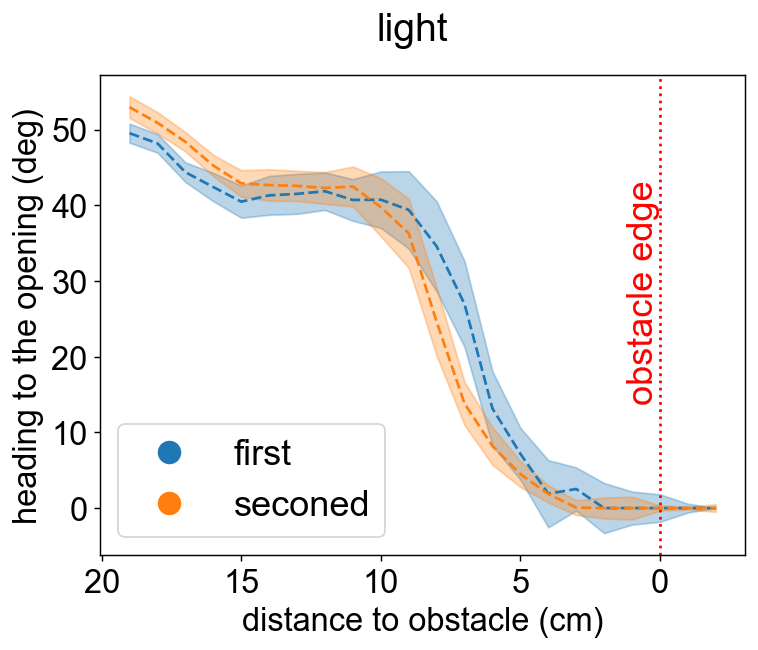

In [73]:
""" Angle to corner comparing fisr and third trials """
xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
ax.invert_xaxis()
fig.suptitle('light')
data = long_con_nostart
long_short = pd.concat([long_con_nostart,short_con_nostart])
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
data = drop_nans_in_columns(data,'speed')

first_trial = data[(data.task == 'oa')&(data.consective_type == 0)&(data.turn_to_obstacle == 'towards')]
ind = first_trial.index.to_numpy()+2
third_trial = data[(data.task == 'oa')&(data.consective_type == 2)&(data.turn_to_obstacle == 'towards')]

fist_light_medians = []
fist_dark_medians = []
fist_light_sd = []
fist_dark_sd = []

sec_light_medians = []
sec_dark_medians = []
sec_light_sd = []
sec_dark_sd = []


first_rows = first_trial.shape[0]
first_angle_array = np.empty([first_rows,len(xnew)])
first_angle_array[:] =np.nan 
for i,row in enumerate(first_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        first_angle_array[i] = ynew

first_angle_median= np.nanmedian(first_angle_array,axis = 0)
    
for animal,animal_df in first_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            fist_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

fist_light_medians = np.asarray(fist_light_medians)


for i in list(range(fist_light_medians.shape[1])):
    sd = np.nanstd(fist_light_medians[:,i])/np.sqrt(len(fist_light_medians[:,i]))
    fist_light_sd.append(sd)
fist_light_sd = np.asarray(fist_light_sd)


ax.plot(xnew,first_angle_median,'--',c = 'tab:blue',alpha = 1)
ax.fill_between(xnew, first_angle_median-fist_light_sd, first_angle_median+fist_light_sd, color='tab:blue', alpha=0.3, label='IQR')  
third_rows = third_trial.shape[0]
third_angle_array = np.empty([third_rows,len(xnew)])
third_angle_array[:] =np.nan 
for i,row in enumerate(third_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        third_angle_array[i] = ynew
third_angle_mean = np.nanmean(third_angle_array,axis = 0)
third_angle_median= np.nanmedian(third_angle_array,axis = 0)
for animal,animal_df in third_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            sec_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

sec_light_medians = np.asarray(sec_light_medians)


for i in list(range(sec_light_medians.shape[1])):
    sd = np.nanstd(sec_light_medians[:,i])/np.sqrt(len(sec_light_medians[:,i]))
    sec_light_sd.append(sd)
sec_light_sd = np.asarray(sec_light_sd)
ax.plot(xnew,third_angle_median,'--',c = 'tab:orange',alpha = 1)
ax.fill_between(xnew, third_angle_median-sec_light_sd, third_angle_median+sec_light_sd, color='tab:orange', alpha=0.3, label='IQR')  





ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','tab:orange']]
ax.legend(markers, ['first','seconed'], numpoints=1,loc = 'lower left',fontsize=20)

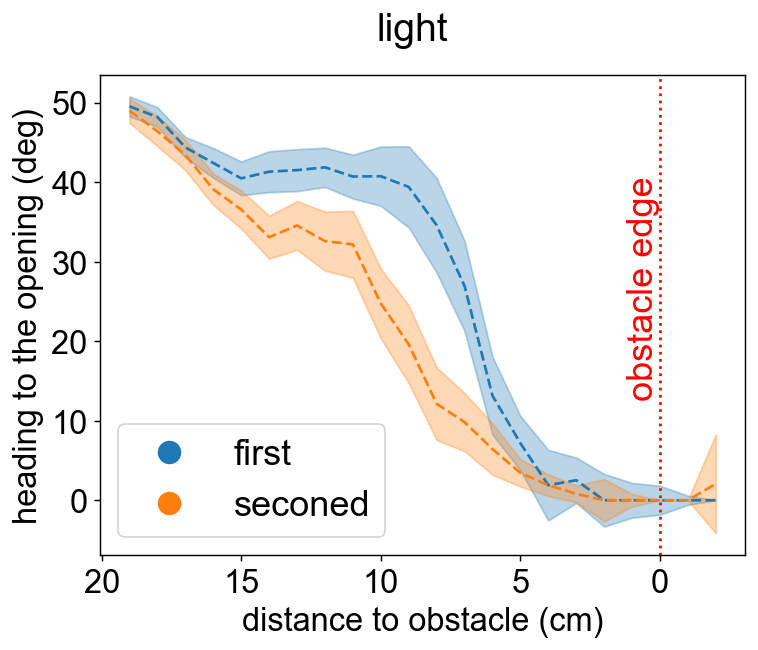

In [70]:
""" Angle to corner comparing fisr and third trials """
xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
ax.invert_xaxis()
fig.suptitle('light')
data = long_con_nostart
long_short = pd.concat([long_con_nostart,short_con_nostart])
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
data = drop_nans_in_columns(data,'speed')

first_trial = data[(data.task == 'oa')&(data.consective_type == 0)&(data.turn_to_obstacle == 'towards')]
ind = first_trial.index.to_numpy()+2
third_trial = long_short.loc[ind.tolist()]

fist_light_medians = []
fist_dark_medians = []
fist_light_sd = []
fist_dark_sd = []

sec_light_medians = []
sec_dark_medians = []
sec_light_sd = []
sec_dark_sd = []


first_rows = first_trial.shape[0]
first_angle_array = np.empty([first_rows,len(xnew)])
first_angle_array[:] =np.nan 
for i,row in enumerate(first_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        first_angle_array[i] = ynew

first_angle_median= np.nanmedian(first_angle_array,axis = 0)
    
for animal,animal_df in first_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            fist_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

fist_light_medians = np.asarray(fist_light_medians)


for i in list(range(fist_light_medians.shape[1])):
    sd = np.nanstd(fist_light_medians[:,i])/np.sqrt(len(fist_light_medians[:,i]))
    fist_light_sd.append(sd)
fist_light_sd = np.asarray(fist_light_sd)


ax.plot(xnew,first_angle_median,'--',c = 'tab:blue',alpha = 1)
ax.fill_between(xnew, first_angle_median-fist_light_sd, first_angle_median+fist_light_sd, color='tab:blue', alpha=0.3, label='IQR')  
third_rows = third_trial.shape[0]
third_angle_array = np.empty([third_rows,len(xnew)])
third_angle_array[:] =np.nan 
for i,row in enumerate(third_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        third_angle_array[i] = ynew
third_angle_mean = np.nanmean(third_angle_array,axis = 0)
third_angle_median= np.nanmedian(third_angle_array,axis = 0)
for animal,animal_df in third_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            sec_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

sec_light_medians = np.asarray(sec_light_medians)


for i in list(range(sec_light_medians.shape[1])):
    sd = np.nanstd(sec_light_medians[:,i])/np.sqrt(len(sec_light_medians[:,i]))
    sec_light_sd.append(sd)
sec_light_sd = np.asarray(sec_light_sd)
ax.plot(xnew,third_angle_median,'--',c = 'tab:orange',alpha = 1)
ax.fill_between(xnew, third_angle_median-sec_light_sd, third_angle_median+sec_light_sd, color='tab:orange', alpha=0.3, label='IQR')  





ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','tab:orange']]
ax.legend(markers, ['first','seconed'], numpoints=1,loc = 'lower left',fontsize=20)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/consecutive/heading_to_opening_light.pdf',dpi = 300)



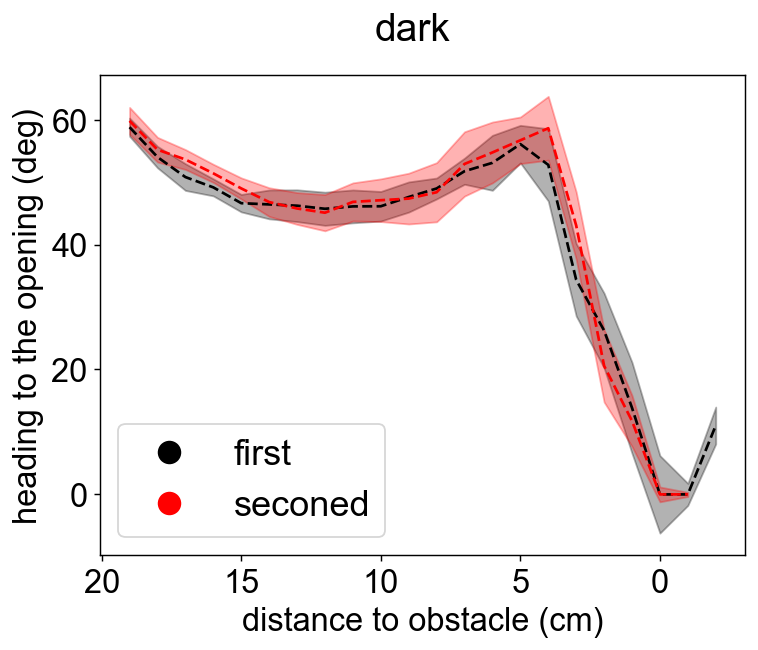

In [74]:
""" Angle to corner comparing fisr and third trials """
xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('dark')
ax.invert_xaxis()
data = long_con_nostart
long_short = pd.concat([long_con_nostart,short_con_nostart])



first_trial = data[(data.task == 'oadark')&(data.consective_type == 0)&(data.turn_to_obstacle == 'towards')]
ind = first_trial.index.to_numpy()+2
third_trial = data[(data.task == 'oadark')&(data.consective_type == 2)&(data.turn_to_obstacle == 'towards')]

fist_light_medians = []
fist_dark_medians = []
fist_light_sd = []
fist_dark_sd = []

sec_light_medians = []
sec_dark_medians = []
sec_light_sd = []
sec_dark_sd = []


first_rows = first_trial.shape[0]
first_angle_array = np.empty([first_rows,len(xnew)])
first_angle_array[:] =np.nan 
for i,row in enumerate(first_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        first_angle_array[i] = ynew

first_angle_median= np.nanmedian(first_angle_array,axis = 0)
    
for animal,animal_df in first_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oadark':
            fist_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

fist_light_medians = np.asarray(fist_light_medians)


for i in list(range(fist_light_medians.shape[1])):
    sd = np.nanstd(fist_light_medians[:,i])/np.sqrt(len(fist_light_medians[:,i]))
    fist_light_sd.append(sd)
fist_light_sd = np.asarray(fist_light_sd)


ax.plot(xnew,first_angle_median,'--',c = 'black',alpha = 1)
ax.fill_between(xnew, first_angle_median-fist_light_sd, first_angle_median+fist_light_sd, color='black', alpha=0.3, label='IQR')  
third_rows = third_trial.shape[0]
third_angle_array = np.empty([third_rows,len(xnew)])
third_angle_array[:] =np.nan 
for i,row in enumerate(third_trial.iterrows()):
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    if sum(y) == 0:
        continue
    else:
        #x = resample(x,20)
        #y = resample(np.flip(np.unique(y)),len(x))
        #y = resample(y,len(x))
        interpolater = interp1d(x,y,bounds_error=False)
        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
        ynew = interpolater(xnew)
        third_angle_array[i] = ynew
third_angle_mean = np.nanmean(third_angle_array,axis = 0)
third_angle_median= np.nanmedian(third_angle_array,axis = 0)
for animal,animal_df in third_trial.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oadark':
            sec_light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

sec_light_medians = np.asarray(sec_light_medians)


for i in list(range(sec_light_medians.shape[1])):
    sd = np.nanstd(sec_light_medians[:,i])/np.sqrt(len(sec_light_medians[:,i]))
    sec_light_sd.append(sd)
sec_light_sd = np.asarray(sec_light_sd)
ax.plot(xnew,third_angle_median,'--',c = 'red',alpha = 1)
ax.fill_between(xnew, third_angle_median-sec_light_sd, third_angle_median+sec_light_sd, color='red', alpha=0.3, label='IQR')  





ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['black','red']]
ax.legend(markers, ['first','seconed'], numpoints=1,loc = 'lower left',fontsize=20)

#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/consecutive/heading_to_opening_dark.pdf',dpi = 300)

In [63]:
third_trial

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,turn_direction,turn_direction_end,turn_to_obstacle,obstacle_cross,head_corner_angle_velocity_at_head_turn,angle_at_head_turn,distance_traveled_at_head_turn,ts_zero_out_angle_to_target_port,consective_inds,consective_type
12999,12999,46360.353024,46362.696102,"[46360.361177, 46360.377561, 46360.394291, 463...","[[4479, 4480, 4481, 4482, 4483, 4484, 4485, 44...","[683.8014526367188, 684.343017578125, 684.4434...","[274.2901306152344, 274.4637451171875, 274.331...","[670.5647583007812, 672.5235595703125, 672.787...","[268.0815734863281, 267.111083984375, 267.1620...","[677.6337890625, 678.2826538085938, 678.372680...",...,up,down,towards,True,-7.338649,61.278691,26.755775,"[31.478926807763038, 20.057684790380296, 15.89...","[12997, 12998, 12999, 13000, 13001, 13002, 130...",2
14054,14054,64854.217228,64856.818444,"[64854.22656, 64854.243494, 64854.260147, 6485...","[1211, 1212, 1213, 1214, 1215, 1216, 1217, 121...","[92.26492309570312, 91.93260192871094, 92.0242...","[263.339599609375, 263.17291259765625, 263.105...","[97.97978973388672, 97.30668640136719, 97.1688...","[261.6289978027344, 261.6818542480469, 261.643...","[100.1938247680664, 99.78005981445312, 99.7589...",...,up,up,towards,True,-6.086059,80.341844,7.229091,"[18.610860770944655, 12.43332831892301, 12.287...","[14052, 14053, 14054, 14055, 14056, 14057, 140...",2
11902,11902,64707.686912,64710.066764,"[64707.696358, 64707.712371, 64707.728934, 647...","[23598, 23599, 23600, 23601, 23602, 23603, 236...","[99.41232299804688, 98.8412094116211, 98.73159...","[263.5517272949219, 263.324951171875, 263.0360...","[105.20948791503906, 104.66622161865234, 104.2...","[269.2513427734375, 269.0252380371094, 268.542...","[112.05911254882812, 111.15039825439453, 110.4...",...,up,up,towards,True,-9.551987,60.368785,16.588510,"[24.999078654561643, 23.070722261609134, 15.24...","[11900, 11901, 11902, 11903, 11904]",2
12833,12833,44816.617856,44822.221913,"[44816.621888, 44816.63872, 44816.655334, 4481...","[[26049, 26050, 26051, 26052, 26053, 26054, 26...","[680.1461791992188, 681.102783203125, 681.7552...","[273.20941162109375, 274.0499267578125, 274.34...","[666.8712768554688, 667.8570556640625, 669.528...","[266.9649658203125, 268.5489807128906, 268.781...","[674.6004638671875, 675.4031372070312, 675.611...",...,up,up,towards,True,-7.967358,64.092730,56.112590,"[39.0090969179413, 30.1561107531325, 31.486346...","[12831, 12832, 12833]",2
13894,13894,63439.401907,63441.651020,"[63439.417395, 63439.433753, 63439.45079, 6343...","[[25216, 25217, 25218, 25219, 25220, 25221, 25...","[675.5855712890625, 676.364501953125, 676.2167...","[262.71734619140625, 262.0768737792969, 262.21...","[664.7400512695312, 665.403564453125, 665.1979...","[253.4127197265625, 252.84481811523438, 252.46...","[666.3189086914062, 666.9103393554688, 666.876...",...,up,up,towards,True,-5.281404,37.343467,4.206557,"[20.0513488442917, 21.52820152466039, 20.31187...","[13892, 13893, 13894, 13895]",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9768,9768,49201.575692,49205.446656,"[49201.586598, 49201.603404, 49201.619596, 492...","[[41127, 41128, 41129, 41130, 41131, 41132, 41...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[664.7879638671875, 665.10498046875, 665.04986...","[242.25270080566406, 242.9918975830078, 243.12...","[663.125, 664.1991577148438, 665.2054443359375...",...,down,down,towards,True,-5.594564,42.126194,61.224769,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9766, 9767, 9768]",2
10209,10209,44549.109798,44551.260288,"[44549.110105, 44549.12718, 44549.143411, 4454...","[13815, 13816, 13817, 13818, 13819, 13820, 138...","[84.1867446899414, 84.03087615966797, 84.07933...","[242.1675567626953, 242.47598266601562, 242.70...","[90.81784057617188, 90.31363677978516, 90.5829...","[261

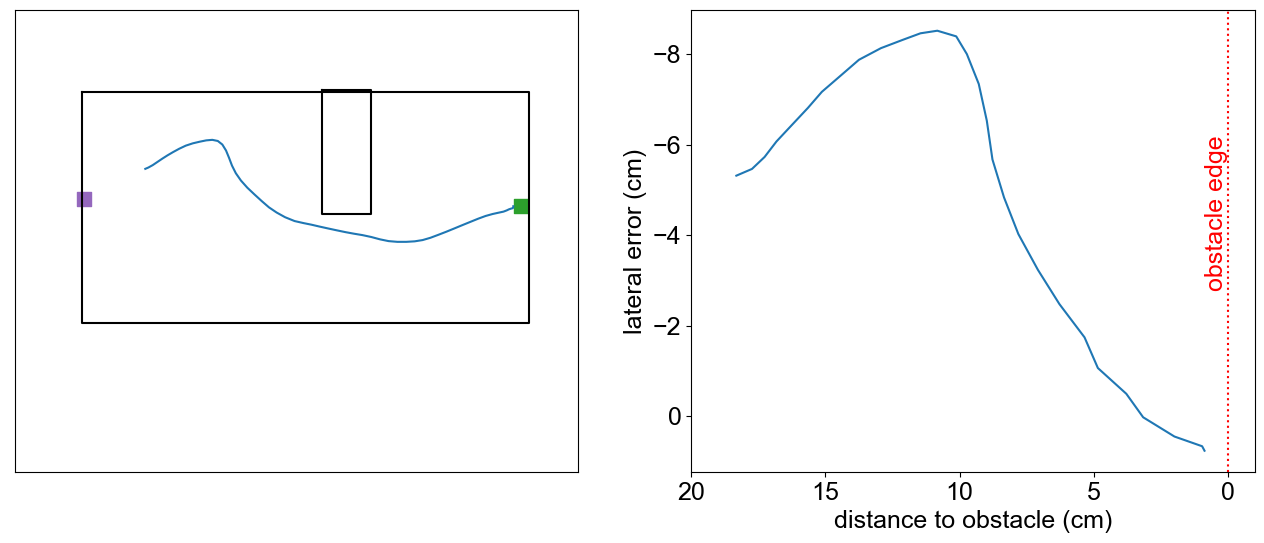

In [141]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('lateral error (cm)')
    ax[1].set_xlabel('distance to obstacle')
    ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:blue')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'tab:blue')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'tab:blue')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision\lateral_error_light.pdf',dpi = 300)

meta NOT subset; don't know how to subset; dropped


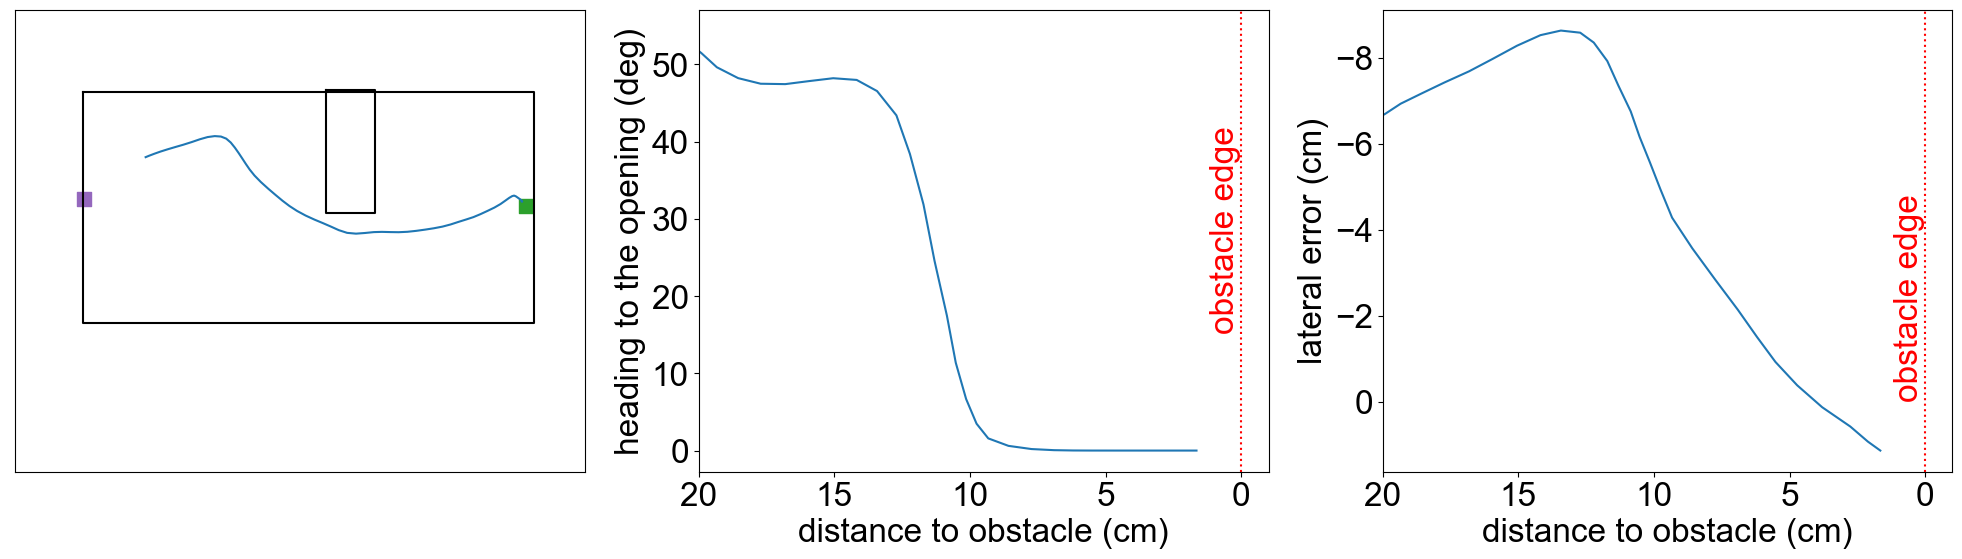

In [229]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[2].set_xticks([0,5,10,15,20])
    ax[2].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[2].invert_xaxis()
    ax[2].invert_yaxis()
    ax[1].set_ylabel('heading to the opening (deg)')
    ax[1].set_xlabel('distance to obstacle (cm)')

    ax[2].set_ylabel('lateral error (cm)')
    ax[2].set_xlabel('distance to obstacle (cm)')
    #ax[2].invert_xaxis()
    plot_arena(data,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(x,y,color = 'tab:blue')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.ts_zero_out_angle_to_corner[:ob_ind],sigma=2),color = 'tab:blue')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        ax[2].axvline(0, color='r', ls=':')
        ax[2].text(0, ax[2].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='bottom', rotation=90)
       
        
        ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'tab:blue')
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'tab:blue')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision/heading_to_opening_lateral_error_light.pdf')

meta NOT subset; don't know how to subset; dropped


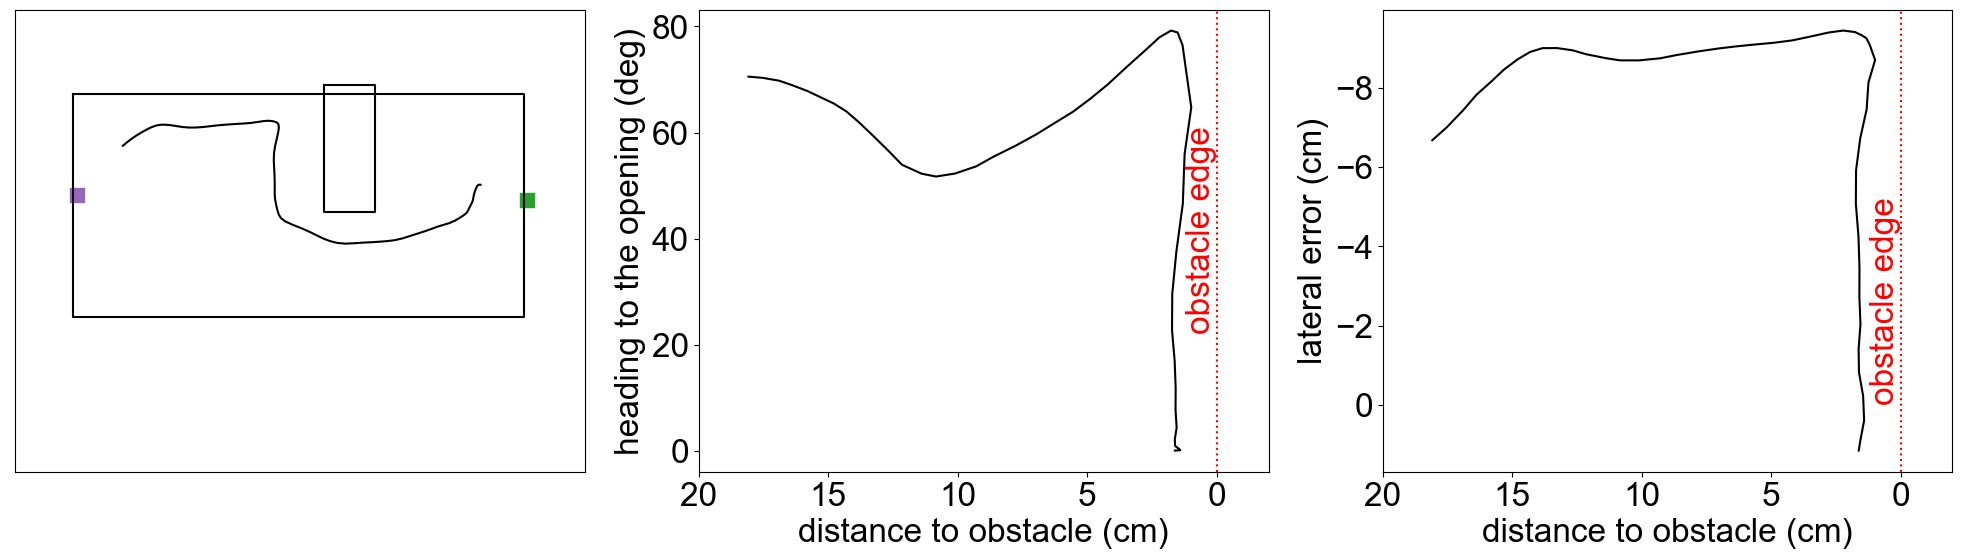

In [216]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-2,20)
    ax[2].set_xticks([0,5,10,15,20])
    ax[2].set_xlim(-2,20)
    ax[1].invert_xaxis()
    ax[2].invert_xaxis()
    ax[2].invert_yaxis()
    ax[1].set_ylabel('heading to the opening (deg)')
    ax[1].set_xlabel('distance to obstacle (cm)')

    ax[2].set_ylabel('lateral error (cm)')
    ax[2].set_xlabel('distance to obstacle (cm)')
    #ax[2].invert_xaxis()
    plot_arena(data,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(x,y,color = 'black')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.ts_zero_out_angle_to_corner[:ob_ind],sigma=2),color = 'black')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        ax[2].axvline(0, color='r', ls=':')
        ax[2].text(0, ax[2].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='bottom', rotation=90)
       
        
        ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision/heading_to_opening_lateral_error_dark.pdf')

meta NOT subset; don't know how to subset; dropped


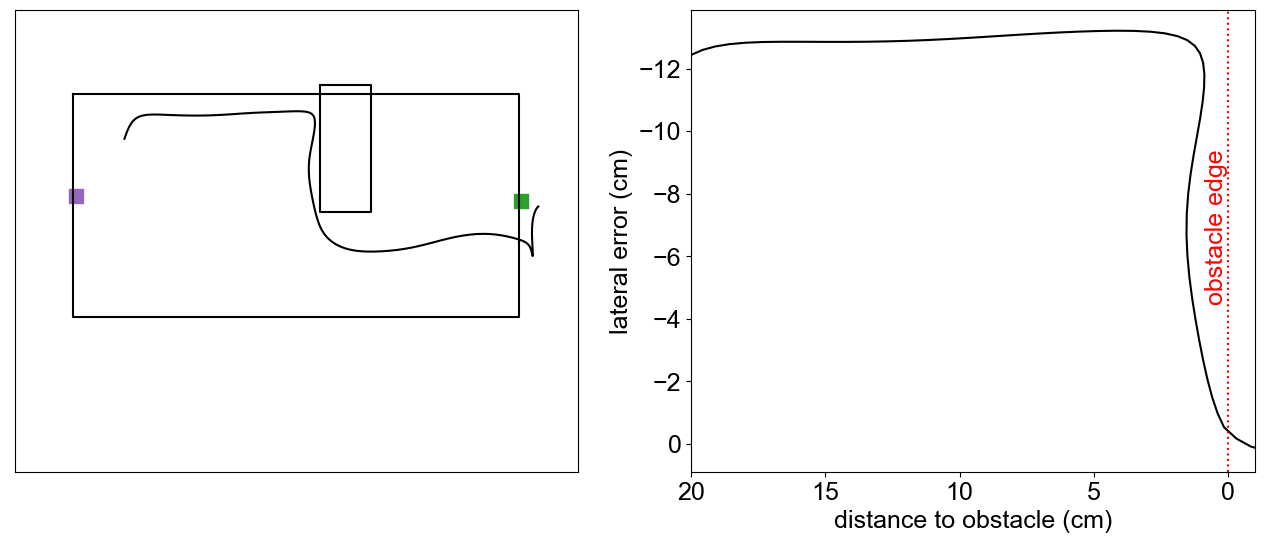

In [111]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('lateral error (cm)')
    ax[1].set_xlabel('distance to obstacle')
    ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'black')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision\lateral_error_dark.pdf',dpi = 300)

In [238]:
 row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)

array([-1.75453462, -1.82225296, -1.95073692, -2.12812356, -2.34089713,
       -2.57702038, -2.82774516, -3.08760602, -3.35296014, -3.62001463,
       -3.88318196, -4.13416772, -4.36196191, -4.55370545, -4.69640889,
       -4.77912955, -4.79496715, -4.74233016, -4.62514642, -4.45219681,
       -4.23589656, -3.99096172, -3.7332316 , -3.47870704, -3.24269788,
       -3.03882515, -2.8777759 , -2.76606655, -2.70516223, -2.69146786,
       -2.71733862, -2.77287355, -2.84807573, -2.93475767, -3.02767965,
       -3.12465595, -3.22569831, -3.33165769, -3.44297601, -3.55902584,
       -3.6781792 , -3.79838502, -3.91786054, -4.03551576, -4.15095153,
       -4.26411998, -4.37489972, -4.48291483, -4.58772012, -4.68920953,
       -4.78784665, -4.88435902, -4.97881077, -5.06955658, -5.15280917,
       -5.22338817, -5.27645652, -5.30932742, -5.32236295, -5.31858031,
       -5.30236717, -5.27809007, -5.24919911, -5.21797052, -5.18569354,
       -5.15299838, -5.12015364, -5.08725944, -5.05435087, -5.02

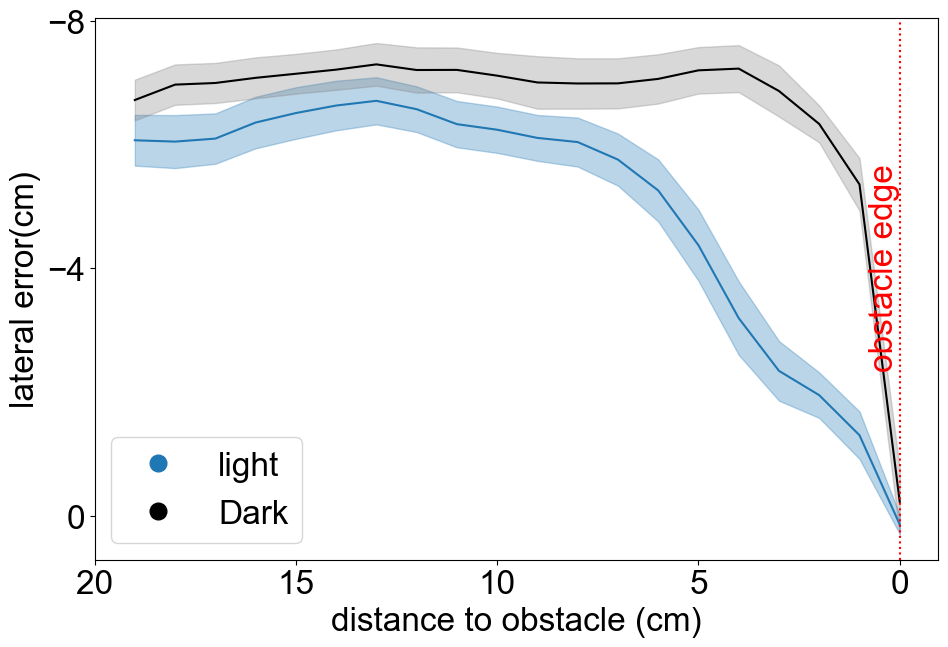

In [112]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )


ax.invert_xaxis()
ax.invert_yaxis()
data = pd.concat([long_nostart,short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])   
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=24)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','Dark'], numpoints=1,loc = 'lower left',fontsize=24)

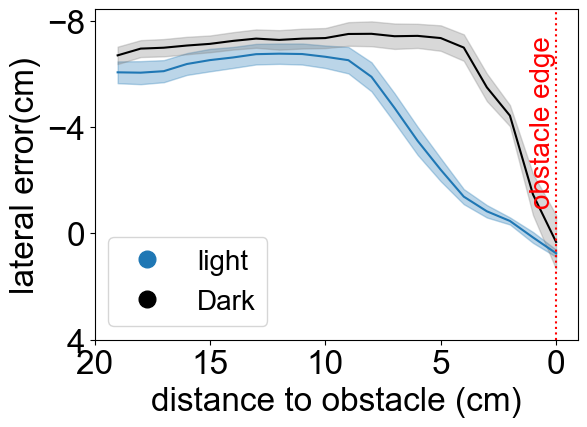

In [237]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
ax.invert_yaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0,4]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/role_of_vision/lateral_error.pdf',dpi = 300)

In [279]:
thresh

29

In [ ]:
row.

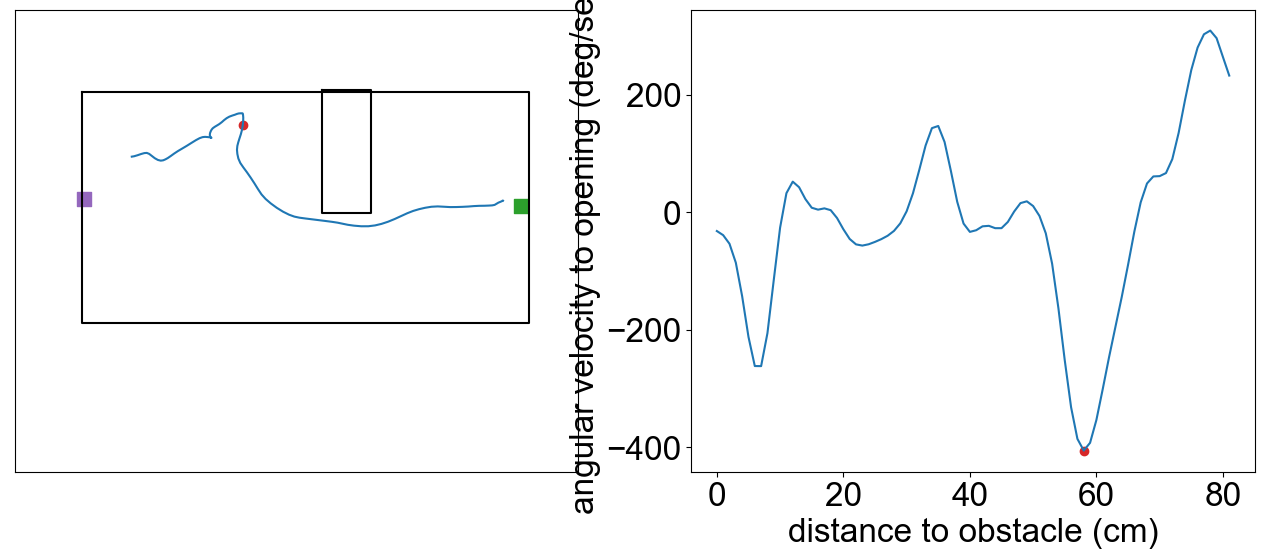

In [292]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks([0,5,10,15,20])
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity to opening (deg/sec)')
    ax[1].set_xlabel('distance to obstacle')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]
    

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = row.head_angle_velocity[:ob_ind].argmin()
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:blue')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'tab:red')
        ax[1].plot(smooth(row.head_angle_velocity[:ob_ind])*60,color = 'tab:blue')
        ax[1].scatter(thresh,smooth(row.head_angle_velocity)[thresh]*60,color = 'tab:red')
        #ax[1].axvline(0, color='r', ls=':')
        #ax[1].text(0, ax[1].get_ylim()[0]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        #fig.savefig(r'd:\obstacle_avoidance\figures\SFN/head_movements/head_turn_light.pdf',dpi = 300)

In [ ]:
 ob_x,ob_y = plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(x,y,color = 'black')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.ts_zero_out_angle_to_corner[:ob_ind],sigma=2),color = 'black')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
        ax[2].axvline(0, color='r', ls=':')
        ax[2].text(0, ax[2].get_ylim()[0]/2,'obstacle edge', color='r', ha='right', va='top', rotation=90)
       
        
        ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')
        #ax[2].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.lateral_error[:ob_ind]),color = 'black')

meta NOT subset; don't know how to subset; dropped


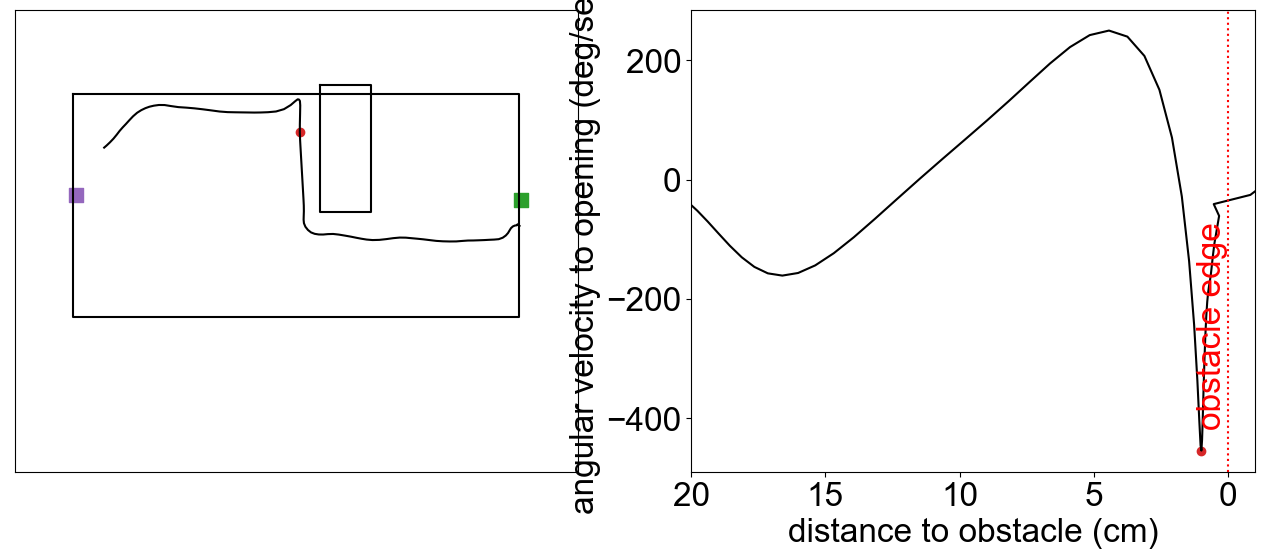

In [202]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity to opening (deg/sec)')
    ax[1].set_xlabel('distance to obstacle')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]
    

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = row.head_corner_angle_velocity[:ob_ind].argmin()
        ax[0].plot(x,y,color = 'black')
        ax[0].scatter(x[thresh],y[thresh],color = 'tab:red')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.head_corner_angle_velocity[:ob_ind])*60,color = 'black')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][thresh],smooth(row.head_corner_angle_velocity)[thresh]*60,color = 'tab:red')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[0]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
    fig.savefig(r'd:\obstacle_avoidance\figures\SFN/distance_at_head_turn/head_turn_dark.pdf',dpi = 300)

In [123]:
row[1]['ts_distance_from_target_port']

nan

In [122]:
row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)

TypeError: 'float' object is not subscriptable

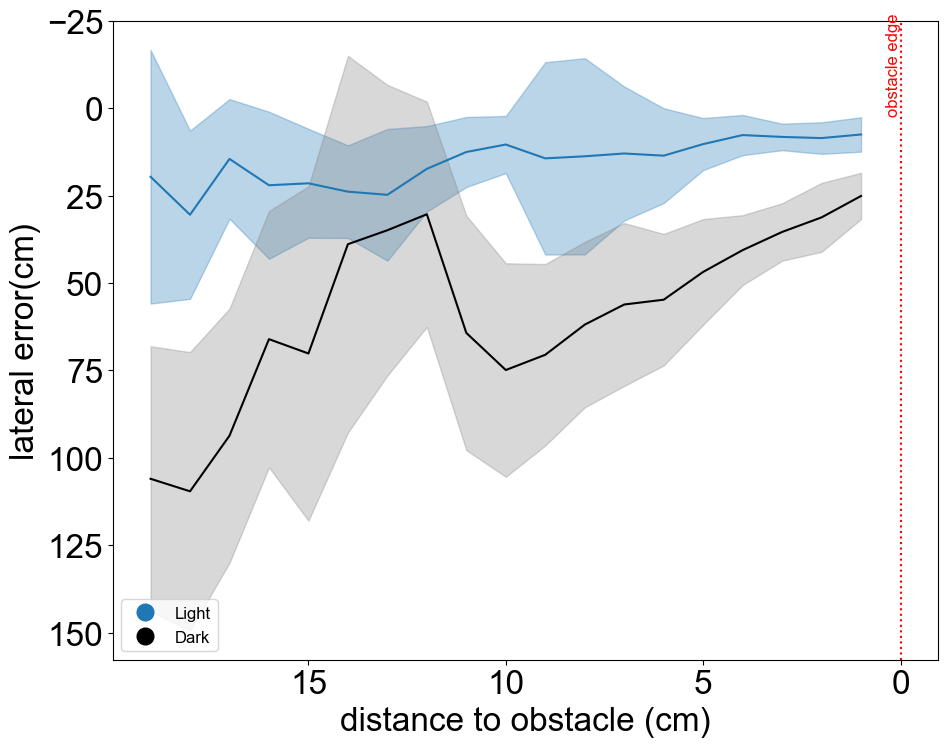

In [102]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,8) )

ax.invert_xaxis()
ax.invert_yaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
        y = row[1]['ts_angle_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            y = row[1]['ts_angle_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
#ax.set_xticks([20,15,10,5,0])    
#ax.set_yticks([-8,-4,0,4]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=12)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)